# Notebook 09 - DAPTS paper findings (executed)

**Objetivo.** Mantener una copia ejecutada de la narrativa de paper con outputs listos para revisar.

**Pregunta guia.** Los resultados renderizados coinciden con la historia experimental del paper?

**Lectura esperada.** Usalo para inspeccionar salidas; edita preferentemente `paper_findings.ipynb` y regenera esta copia.

**Formato.** Cada bloque sigue el mismo patron: contexto breve, parametros (`n`, `B`, `G`, `p`, `u`), calculo reproducible y salida interpretada cerca del codigo.

## Setup

Imports, path del repo y parametros graficos compartidos.

In [1]:
# === Setup: All imports ===
import sys, os, time
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from matplotlib.patches import Patch

from augmented.core import (
    mask_from_indices, indices_from_mask, mask_str,
    all_pools, all_pools_from_mask, compute_active_mask, popcount,
)
from augmented.bayesian import (
    bayesian_update_single_test, bayesian_update_by_counting,
    gibbs_update, _poisson_binomial_pmf,
)
from augmented.solver import solve_optimal_dapts
from augmented.classical_solver import solve_classical_dynamic
from augmented.static_solver import solve_static_non_overlapping, solve_static_overlapping
from augmented.greedy import (
    greedy_myopic_expected_utility,
    greedy_myopic_counting_expected_utility,
    _myopic_best_pool,
)
from augmented.baselines import u_max, u_single
from augmented.tree_extractor import (
    extract_tree, print_tree, summarize_tree, prune_tree,
)
from augmented.tree_visualizer import (
    render_tree, render_side_by_side, render_tree_series,
)
from augmented.hybrid_solver import (
    hybrid_greedy_bruteforce,
    estimate_branch_value,
    expected_info_gain,
    infection_aware_score,
    _infection_aware_best_pool,
)
from augmented.infection_reward_greedy import (
    greedy_myopic_beta_expected_utility, _beta_best_pool,
)
from augmented.semi_utility import greedy_myopic_semi_expected_utility

# Style
matplotlib.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

C_OPT     = '#27ae60'   # green - optimal / augmented dynamic
C_GREEDY  = '#e74c3c'   # red - greedy
C_HYBRID  = '#2980b9'   # blue - hybrid
C_BETA    = '#ff7f0e'   # orange
C_INFO    = '#8e44ad'   # purple
C_UMAX    = '#e74c3c'   # red dashed - upper bound
C_CLS     = '#95a5a6'   # gray - classical
C_STATIC  = '#f39c12'   # amber - static

SAVE_FIGS = True

def savefig(name):
    if SAVE_FIGS:
        os.makedirs('paper_figs', exist_ok=True)
        plt.savefig(f'paper_figs/{name}.png', bbox_inches='tight', dpi=150)

print('All imports OK. Ready.')


All imports OK. Ready.


## Notebook map

**Structure optimized for paper narrative**

1. [Part 1: Building Intuition](#part1) — 3 key examples
2. [Part 2: Central Benchmark](#part2) — Full strategy chain
3. [Part 3: When Does Augmentation Help?](#part3) — Regime map + G sweep
4. [Part 3B: Large Budget Analysis](#part3b) — B=1..8, VIP saturation
5. [Part 3C: Cross-Test Information](#part3c) — The key mechanism *(NEW)*
6. [Part 4: Solver Benchmark & Scalability](#part4) — Pareto + transition zone n=10-14
7. [Part 4B: When Does Greedy Suffice?](#part4) — Gap heatmap *(NEW)*
8. [Part 5: Robustness](#part5) — Augmented vs Classical under misspecification
9. [Part 6: Distributional Risk Analysis](#part6)
10. [Part 7: Realistic Scenarios](#part7) — Including extreme (p>0.7) + bimodal
11. [Appendix A: Gibbs Sampling Verification](#appA)
12. [Appendix B: Hybrid Solver Trade-off](#appB)
13. [Appendix C: Scoring Meta-parameters (alpha, beta)](#appC)
14. [Appendix D: Thesis Comparisons (Nico)](#appD)


<a id='part1'></a>

---
# Part 1: Building Intuition

Three compact examples that build the core intuition:
1. **Pooling wins** when prevalence is low (n=2)
2. **Augmented > Classical** — the count r gives better posteriors (n=3)
3. **Pooling vs Individual testing** — when does pooling help? (n=4)


### 1.1 The Simplest Case — n=2, B=1, G=2

Two people, one test, equal p=0.2, unit utility.
Testing them together (pooling) yields EU = 0.64×2 = 1.28 vs testing one alone EU = 0.80.


In [2]:
# --- 1.1 Simplest Case ---
n, B, G = 2, 1, 2
p = [0.2, 0.2]
u = [1.0, 1.0]

eu_A = 0.8 * 1.0
eu_B = 0.64 * 2.0

print(f'Strategy A (test {{0}} alone):  EU = {eu_A:.2f}')
print(f'Strategy B (pool {{0,1}}):      EU = {eu_B:.2f}')
print(f'Pooling wins by {eu_B - eu_A:.2f} expected utility.')
print()

val_opt, policy_opt = solve_optimal_dapts(p, u, B, G)
print(f'Optimal DP confirms: {val_opt:.4f}')

pool_A = mask_from_indices([0])
tree_A = {
    'step': 1, 'terminal': False,
    'pool': pool_A, 'pool_str': mask_str(pool_A, n),
    'history': (), 'cleared': 0, 'cleared_str': mask_str(0, n),
    'posteriors': list(p),
    'children': {
        0: {'step': 2, 'terminal': True, 'history': ((pool_A, 0),),
            'cleared': pool_A, 'cleared_str': mask_str(pool_A, n),
            'posteriors': [0.0, 0.2], 'utility': 1.0},
        1: {'step': 2, 'terminal': True, 'history': ((pool_A, 1),),
            'cleared': 0, 'cleared_str': mask_str(0, n),
            'posteriors': [1.0, 0.2], 'utility': 0.0},
    }
}

pool_B = mask_from_indices([0, 1])
tree_B = {
    'step': 1, 'terminal': False,
    'pool': pool_B, 'pool_str': mask_str(pool_B, n),
    'history': (), 'cleared': 0, 'cleared_str': mask_str(0, n),
    'posteriors': list(p),
    'children': {
        0: {'step': 2, 'terminal': True, 'history': ((pool_B, 0),),
            'cleared': pool_B, 'cleared_str': mask_str(pool_B, n),
            'posteriors': [0.0, 0.0], 'utility': 2.0},
        1: {'step': 2, 'terminal': True, 'history': ((pool_B, 1),),
            'cleared': 0, 'cleared_str': mask_str(0, n),
            'posteriors': [0.5, 0.5], 'utility': 0.0},
        2: {'step': 2, 'terminal': True, 'history': ((pool_B, 2),),
            'cleared': 0, 'cleared_str': mask_str(0, n),
            'posteriors': [1.0, 1.0], 'utility': 0.0},
    }
}

display(render_side_by_side(
    tree_A, tree_B, n,
    title_a=f'A: test {{0}} alone (EU={eu_A:.2f})',
    title_b=f'B: pool {{0,1}} (EU={eu_B:.2f})',
    show_posteriors=True,
))


Strategy A (test {0} alone):  EU = 0.80
Strategy B (pool {0,1}):      EU = 1.28
Pooling wins by 0.48 expected utility.

Optimal DP confirms: 1.2800


### 1.2 Augmented vs Classical — n=3, B=2, G=3

The augmented test returns the exact count r = |pool ∩ Z|, while the
classical test returns only positive/negative. More information should
yield better decisions.


Augmented optimal EU: 6.6350
Classical  optimal EU: 6.5450
Augmented advantage:  +0.0900 (+1.38%)


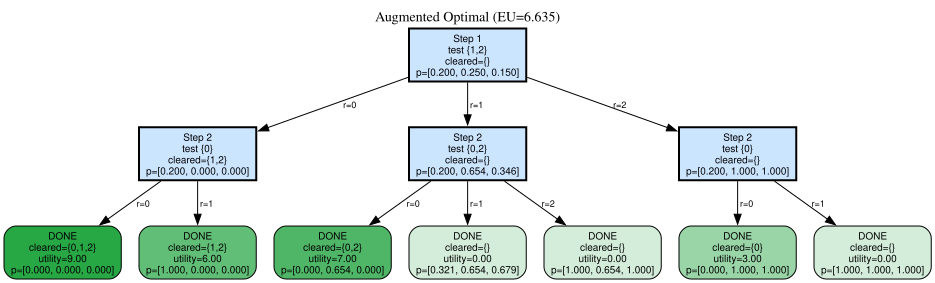

In [3]:
# --- 1.2 Augmented vs Classical ---
n, B, G = 3, 2, 3
p = [0.2, 0.25, 0.15]
u = [3.0, 2.0, 4.0]

val_aug, pol_aug = solve_optimal_dapts(p, u, B, G)
val_cls, _ = solve_classical_dynamic(p, u, B, G)

tree_aug = extract_tree(pol_aug, p, u, n)

print(f'Augmented optimal EU: {val_aug:.4f}')
print(f'Classical  optimal EU: {val_cls:.4f}')
print(f'Augmented advantage:  +{val_aug - val_cls:.4f} '
      f'(+{(val_aug - val_cls) / val_cls * 100:.2f}%)')

display(render_tree(tree_aug, n, title=f'Augmented Optimal (EU={val_aug:.3f})'))


### 1.3 "Why Not Test One by One?" — n=4, B=2, G in {1..4}

Fixed budget B=2, varying maximum pool size G. G=1 forces individual
testing; larger G unlocks pooling.


In [4]:
# --- 1.3 Pooling vs Individual ---
n, B = 4, 2
p = [0.15] * n
u = [1.0] * n

for G in [1, 2, 3, 4]:
    val, pol = solve_optimal_dapts(p, u, B, G)
    eu_umax = u_max(p, u)
    print(f'G={G}: optimal EU = {val:.4f}  (U_max = {eu_umax:.4f}, '
          f'captured = {val/eu_umax*100:.1f}%)')


G=1: optimal EU = 1.7000  (U_max = 3.4000, captured = 50.0%)
G=2: optimal EU = 2.8900  (U_max = 3.4000, captured = 85.0%)
G=3: optimal EU = 2.8900  (U_max = 3.4000, captured = 85.0%)
G=4: optimal EU = 2.8900  (U_max = 3.4000, captured = 85.0%)


> **Part 1 Takeaway**: Pooling wins when prevalence is low. Augmented counts
> give strictly better posteriors than binary results. These effects compound
> with budget and pool size.


<a id='part2'></a>

---
# Part 2: Central Benchmark — Full Strategy Chain

The core scientific question: how much of the gain comes from
**adaptivity**, how much from **augmentation**, and how much from **pooling/overlap**?

We compare the full chain:
$$U_{single} \leq U^s_{NO} \leq U^s_{O} \leq U^D \leq U^D_A \leq U_{max}$$

Over a grid of random instances.


In [5]:
# --- Central Benchmark: Full Strategy Chain ---
np.random.seed(42)

N_INSTANCES = 10
n_values = [4, 5, 6]
B_values = [2, 3]
G_values = [3]

all_results = []

for n in n_values:
    for B in B_values:
        for G in G_values:
            for inst in range(N_INSTANCES):
                p_inst = np.random.uniform(0.05, 0.5, size=n).tolist()
                u_inst = np.random.uniform(1, 10, size=n).tolist()

                eu_umax = u_max(p_inst, u_inst)
                eu_usingle, _ = u_single(p_inst, u_inst, B)
                eu_static_no, _ = solve_static_non_overlapping(p_inst, u_inst, B, G)
                eu_static_o, _ = solve_static_overlapping(p_inst, u_inst, B, G)
                eu_cls, _ = solve_classical_dynamic(p_inst, u_inst, B, G)
                eu_aug, _ = solve_optimal_dapts(p_inst, u_inst, B, G)

                all_results.append({
                    'n': n, 'B': B, 'G': G, 'inst': inst,
                    'U_single': eu_usingle,
                    'U_s_NO': eu_static_no,
                    'U_s_O': eu_static_o,
                    'U_D': eu_cls,
                    'U_D_A': eu_aug,
                    'U_max': eu_umax,
                })

            print(f'Done: n={n}, B={B}, G={G} ({N_INSTANCES} instances)')

df_bench = pd.DataFrame(all_results)
print(f'\nTotal instances: {len(df_bench)}')


Done: n=4, B=2, G=3 (10 instances)
Done: n=4, B=3, G=3 (10 instances)


Done: n=5, B=2, G=3 (10 instances)


Done: n=5, B=3, G=3 (10 instances)


Done: n=6, B=2, G=3 (10 instances)


Done: n=6, B=3, G=3 (10 instances)

Total instances: 60


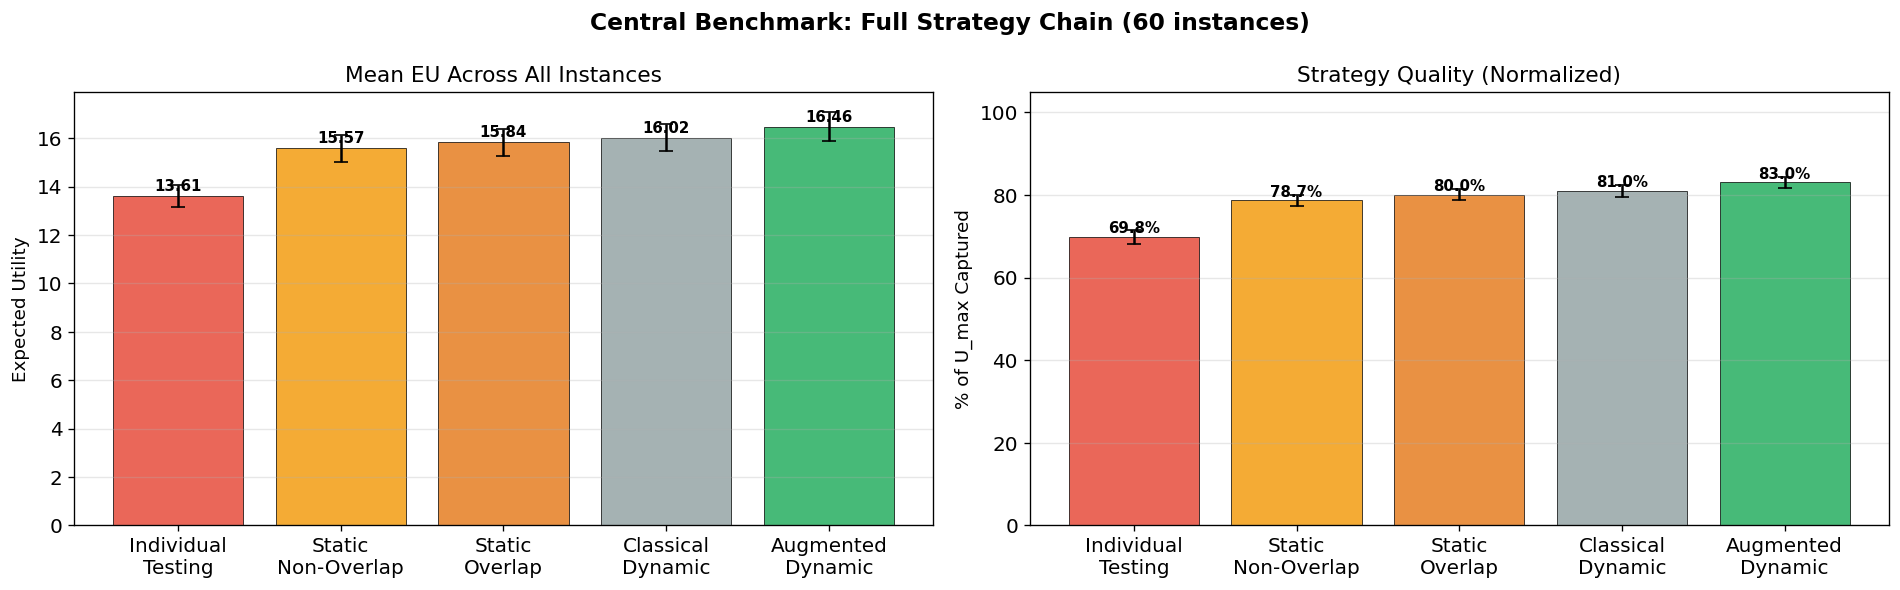

In [6]:
# --- Figure 1: Strategy Chain Bar Chart (aggregated) ---
strategies = ['U_single', 'U_s_NO', 'U_s_O', 'U_D', 'U_D_A']
labels = ['Individual\nTesting', 'Static\nNon-Overlap', 'Static\nOverlap',
          'Classical\nDynamic', 'Augmented\nDynamic']
colors = [C_GREEDY, C_STATIC, '#e67e22', C_CLS, C_OPT]

# Normalize by U_max per instance
for s in strategies:
    df_bench[f'{s}_norm'] = df_bench[s] / df_bench['U_max']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: absolute means with error bars
ax = axes[0]
means = [df_bench[s].mean() for s in strategies]
stds = [df_bench[s].std() / np.sqrt(len(df_bench)) for s in strategies]
bars = ax.bar(labels, means, yerr=stds, color=colors, alpha=0.85,
              edgecolor='black', linewidth=0.5, capsize=4)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{m:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Expected Utility')
ax.set_title('Mean EU Across All Instances')
ax.grid(True, axis='y', alpha=0.3)

# Right: normalized by U_max (% of upper bound captured)
ax = axes[1]
norm_means = [df_bench[f'{s}_norm'].mean() * 100 for s in strategies]
norm_stds = [df_bench[f'{s}_norm'].std() / np.sqrt(len(df_bench)) * 100 for s in strategies]
bars = ax.bar(labels, norm_means, yerr=norm_stds, color=colors, alpha=0.85,
              edgecolor='black', linewidth=0.5, capsize=4)
for bar, m in zip(bars, norm_means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{m:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('% of U_max Captured')
ax.set_title('Strategy Quality (Normalized)')
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 105)

plt.suptitle(f'Central Benchmark: Full Strategy Chain ({len(df_bench)} instances)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('central_benchmark_chain')
plt.show()


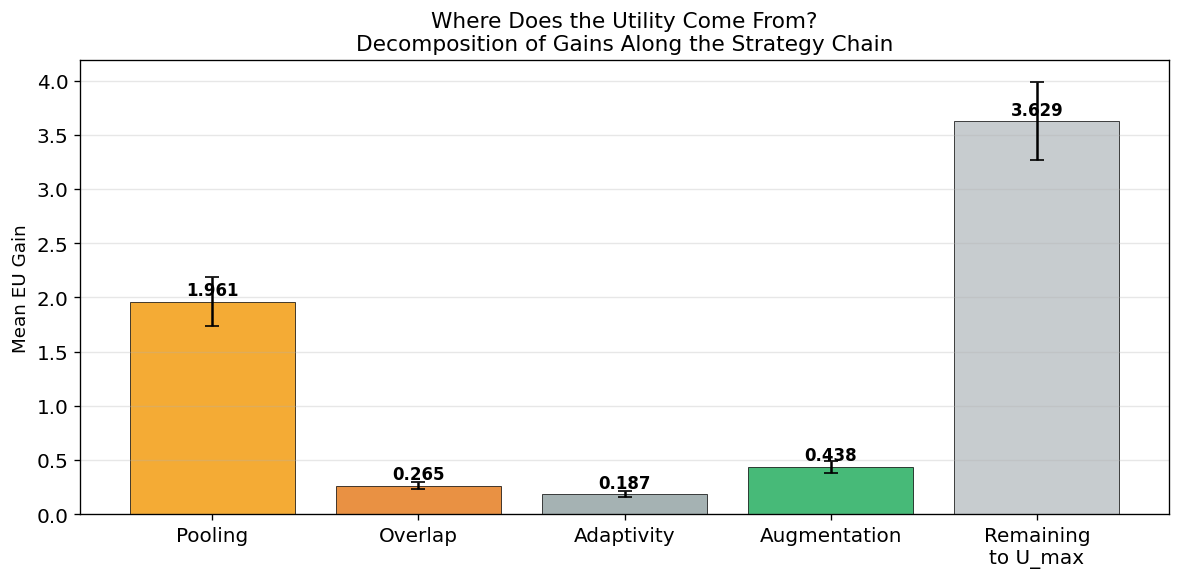


Gain Decomposition Summary:
Source                   Mean      Std  % of total gap
Pooling                1.9608   1.7659           30.3%
Overlap                0.2654   0.2662            4.1%
Adaptivity             0.1868   0.2277            2.9%
Augmentation           0.4380   0.4123            6.8%


In [7]:
# --- Figure 2: Decompose the gains ---
# Gain from pooling: U_s_NO - U_single
# Gain from overlap: U_s_O - U_s_NO
# Gain from adaptivity: U_D - U_s_O
# Gain from augmentation: U_D_A - U_D

df_bench['gain_pooling'] = df_bench['U_s_NO'] - df_bench['U_single']
df_bench['gain_overlap'] = df_bench['U_s_O'] - df_bench['U_s_NO']
df_bench['gain_adaptivity'] = df_bench['U_D'] - df_bench['U_s_O']
df_bench['gain_augmentation'] = df_bench['U_D_A'] - df_bench['U_D']
df_bench['remaining_gap'] = df_bench['U_max'] - df_bench['U_D_A']

gain_cols = ['gain_pooling', 'gain_overlap', 'gain_adaptivity',
             'gain_augmentation', 'remaining_gap']
gain_labels = ['Pooling', 'Overlap', 'Adaptivity', 'Augmentation', 'Remaining\nto U_max']
gain_colors = [C_STATIC, '#e67e22', C_CLS, C_OPT, '#bdc3c7']

fig, ax = plt.subplots(figsize=(10, 5))

means = [df_bench[c].mean() for c in gain_cols]
stds = [df_bench[c].std() / np.sqrt(len(df_bench)) for c in gain_cols]

bars = ax.bar(gain_labels, means, yerr=stds, color=gain_colors, alpha=0.85,
              edgecolor='black', linewidth=0.5, capsize=4)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, max(m, 0) + 0.02,
            f'{m:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Mean EU Gain')
ax.set_title('Where Does the Utility Come From?\nDecomposition of Gains Along the Strategy Chain')
ax.grid(True, axis='y', alpha=0.3)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
savefig('gain_decomposition')
plt.show()

# Print summary table
print('\nGain Decomposition Summary:')
print(f"{'Source':<20} {'Mean':>8} {'Std':>8} {'% of total gap':>15}")
total_gap = df_bench['U_max'].mean() - df_bench['U_single'].mean()
for col, label in zip(gain_cols[:-1], gain_labels[:-1]):
    m = df_bench[col].mean()
    s = df_bench[col].std()
    print(f'{label:<20} {m:>8.4f} {s:>8.4f} {m/total_gap*100:>14.1f}%')


In [8]:
# --- Figure 3: Strategy chain by (n, B) configuration ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

strategies = ['U_single', 'U_s_NO', 'U_s_O', 'U_D', 'U_D_A', 'U_max']
strat_labels = ['U_single', 'Static NO', 'Static O', 'Classical D', 'Augmented D', 'U_max']
strat_colors = [C_GREEDY, C_STATIC, '#e67e22', C_CLS, C_OPT, C_UMAX]

for i, n in enumerate(n_values):
    for j, B in enumerate(B_values):
        ax = axes[j][i]
        subset = df_bench[(df_bench['n'] == n) & (df_bench['B'] == B)]
        means = [subset[s].mean() for s in strategies]
        stds = [subset[s].std() / np.sqrt(len(subset)) for s in strategies]

        bars = ax.bar(strat_labels, means, yerr=stds, color=strat_colors,
                      alpha=0.85, edgecolor='black', linewidth=0.5, capsize=3)
        ax.set_title(f'n={n}, B={B}', fontweight='bold')
        ax.tick_params(axis='x', rotation=45, labelsize=8)
        ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Strategy Chain by Configuration (G averaged)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('strategy_chain_by_config')
plt.show()


> **Part 2 Takeaway**: The full chain U_single ≤ U^s_NO ≤ U^s_O ≤ U^D ≤ U^D_A ≤ U_max
> holds across all instances. The gain decomposition shows where the utility comes from:
> pooling, overlap, adaptivity, and augmentation each contribute distinct value.


<a id='part3'></a>

---
# Part 3: When Does Augmentation Help?

A regime map showing the **augmented advantage** (U^D_A - U^D) / U^D
across mean prevalence and pool size G. This answers the reviewer question:
"When does it actually matter to have augmented (count) test results?"


p~0.05, G=2: augmented advantage = 0.21%


p~0.05, G=3: augmented advantage = 0.15%


p~0.05, G=4: augmented advantage = 0.28%


p~0.05, G=5: augmented advantage = 0.30%
p~0.10, G=2: augmented advantage = 0.46%


p~0.10, G=3: augmented advantage = 0.93%


...

p~0.50, G=4: augmented advantage = 7.50%


p~0.50, G=5: augmented advantage = 6.28%
p~0.70, G=2: augmented advantage = 6.40%


p~0.70, G=3: augmented advantage = 5.50%


p~0.70, G=4: augmented advantage = 5.88%


p~0.70, G=5: augmented advantage = 5.97%


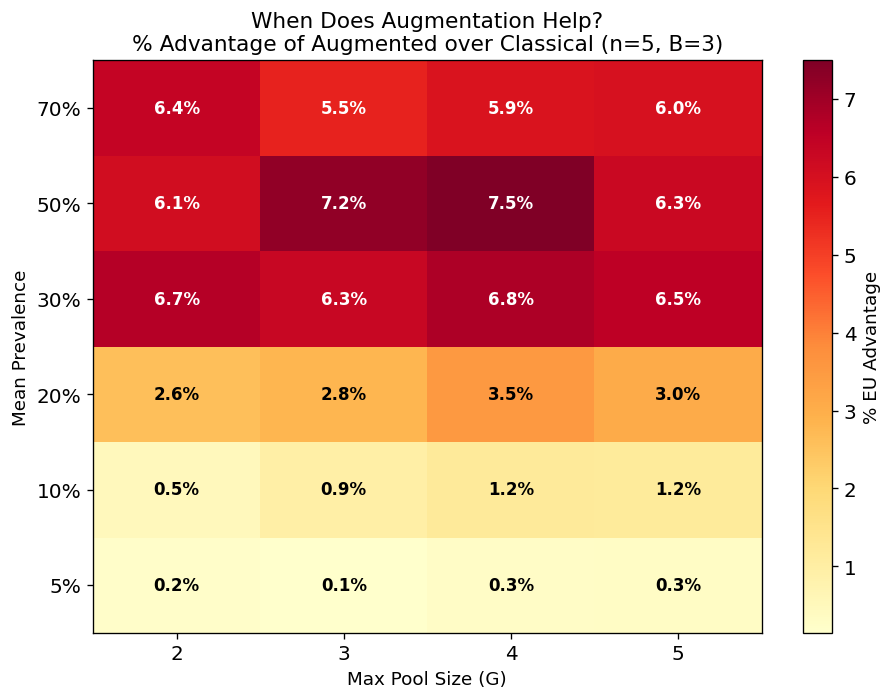

In [9]:
# --- Regime Map: Augmented advantage vs prevalence x G ---
np.random.seed(123)
N_INST = 10
n, B = 5, 3

prevalences = [0.05, 0.1, 0.2, 0.3, 0.5, 0.7]
G_values_map = [2, 3, 4, 5]

heatmap = np.zeros((len(prevalences), len(G_values_map)))

for i, mean_p in enumerate(prevalences):
    for j, G in enumerate(G_values_map):
        advantages = []
        for inst in range(N_INST):
            p_inst = np.clip(np.random.normal(mean_p, 0.05, size=n), 0.01, 0.99).tolist()
            u_inst = np.random.uniform(1, 5, size=n).tolist()

            eu_aug, _ = solve_optimal_dapts(p_inst, u_inst, B, G)
            eu_cls, _ = solve_classical_dynamic(p_inst, u_inst, B, G)

            if eu_cls > 1e-6:
                advantages.append((eu_aug - eu_cls) / eu_cls * 100)
            else:
                advantages.append(0)

        heatmap[i, j] = np.mean(advantages)
        print(f'p~{mean_p:.2f}, G={G}: augmented advantage = {heatmap[i,j]:.2f}%')

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(heatmap, cmap='YlOrRd', aspect='auto', origin='lower')
ax.set_xticks(range(len(G_values_map)))
ax.set_xticklabels(G_values_map)
ax.set_yticks(range(len(prevalences)))
ax.set_yticklabels([f'{p:.0%}' for p in prevalences])
ax.set_xlabel('Max Pool Size (G)')
ax.set_ylabel('Mean Prevalence')
ax.set_title(f'When Does Augmentation Help?\n% Advantage of Augmented over Classical (n={n}, B={B})')

for i in range(len(prevalences)):
    for j in range(len(G_values_map)):
        ax.text(j, i, f'{heatmap[i,j]:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if heatmap[i,j] > heatmap.max()*0.6 else 'black')

plt.colorbar(im, label='% EU Advantage')
plt.tight_layout()
savefig('regime_map_augmentation')
plt.show()


In [10]:
# --- G Sweep: ALL strategies vs pool size ---
np.random.seed(42)
n_gs, B_gs = 6, 3
G_sweep = [1, 2, 3, 4, 5, 6]
N_INST_GS = 8

# Use PAIRED instances (same seed across G)
base_instances = []
for inst in range(N_INST_GS):
    rng = np.random.RandomState(inst)
    base_instances.append({
        'p': rng.uniform(0.1, 0.4, size=n_gs).tolist(),
        'u': rng.uniform(1, 8, size=n_gs).tolist(),
    })

g_results = {s: [] for s in ['U_single', 'U_s_O', 'U_D', 'U_D_A']}

for G in G_sweep:
    vals = {s: [] for s in g_results}
    for inst_data in base_instances:
        p_i, u_i = inst_data['p'], inst_data['u']
        eu_us, _ = u_single(p_i, u_i, B_gs)
        eu_so, _ = solve_static_overlapping(p_i, u_i, B_gs, G)
        eu_cls, _ = solve_classical_dynamic(p_i, u_i, B_gs, G)
        eu_aug, _ = solve_optimal_dapts(p_i, u_i, B_gs, G)
        vals['U_single'].append(eu_us)
        vals['U_s_O'].append(eu_so)
        vals['U_D'].append(eu_cls)
        vals['U_D_A'].append(eu_aug)
    for s in g_results:
        g_results[s].append(np.mean(vals[s]))
    print(f'G={G}: U_single={np.mean(vals["U_single"]):.3f}, '
          f'Static_O={np.mean(vals["U_s_O"]):.3f}, '
          f'Classical={np.mean(vals["U_D"]):.3f}, '
          f'Augmented={np.mean(vals["U_D_A"]):.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors_gs = {'U_single': C_GREEDY, 'U_s_O': C_STATIC, 'U_D': C_CLS, 'U_D_A': C_OPT}
labels_gs = {'U_single': 'Individual', 'U_s_O': 'Static Overlap',
             'U_D': 'Classical Dynamic', 'U_D_A': 'Augmented Dynamic'}
markers_gs = {'U_single': 'v', 'U_s_O': '^', 'U_D': 's', 'U_D_A': 'o'}

for s in g_results:
    ax1.plot(G_sweep, g_results[s], f'{markers_gs[s]}-', color=colors_gs[s],
             linewidth=2, markersize=8, label=labels_gs[s])
ax1.set_xlabel('Max Pool Size (G)')
ax1.set_ylabel('Mean Expected Utility')
ax1.set_title(f'All Strategies vs Pool Size (n={n_gs}, B={B_gs})')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: gap between augmented and classical
gap_aug_cls = [a - c for a, c in zip(g_results['U_D_A'], g_results['U_D'])]
gap_aug_static = [a - s for a, s in zip(g_results['U_D_A'], g_results['U_s_O'])]
ax2.plot(G_sweep, gap_aug_cls, 'o-', color=C_OPT, linewidth=2, markersize=8,
         label='Augmented - Classical')
ax2.plot(G_sweep, gap_aug_static, 's--', color=C_HYBRID, linewidth=2, markersize=8,
         label='Augmented - Static')
ax2.set_xlabel('Max Pool Size (G)')
ax2.set_ylabel('Mean EU Gap')
ax2.set_title('Advantage of Augmented Dynamic vs G')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.5)

plt.suptitle(f'Systematic G Sweep — Paired Instances (n={n_gs}, B={B_gs}, {N_INST_GS} inst)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('g_sweep_all_strategies')
plt.show()


G=1: U_single=12.213, Static_O=12.213, Classical=12.213, Augmented=12.213


G=2: U_single=12.213, Static_O=14.506, Classical=14.685, Augmented=15.312


G=3: U_single=12.213, Static_O=14.569, Classical=14.737, Augmented=15.448


G=4: U_single=12.213, Static_O=14.569, Classical=14.737, Augmented=15.474


G=5: U_single=12.213, Static_O=14.569, Classical=14.737, Augmented=15.474


G=6: U_single=12.213, Static_O=14.569, Classical=14.737, Augmented=15.474


> **Part 3 Takeaway**: Augmentation helps most at moderate-to-high prevalence and larger pool sizes.
> The G sweep shows all strategies improve with G, but augmented dynamic benefits disproportionately
> because larger pools generate richer count information. At G=1 (individual testing),
> augmented and classical are identical.


<a id='part3b'></a>

---
# Part 3B: Large Budget Analysis — Where Augmentation Shines

The augmented test's main theoretical advantage is **better Bayesian updates
after positive results**. With more tests (larger B), there are more opportunities
for information to accumulate. This section tests the hypothesis that the
augmented advantage grows with B.

We use the hybrid solver to handle larger B values (up to B=8) which are
computationally infeasible for full DP.


In [11]:
# --- Large B: Augmented advantage grows with budget ---
np.random.seed(42)
n_lb = 6
G_lb = 3
B_range_large = range(1, 7)  # B = 1..6 (B=7+ too slow for DP)
N_INST_LB = 8

# Paired instances: same across all B values
base_lb = []
for inst in range(N_INST_LB):
    rng = np.random.RandomState(inst + 100)
    base_lb.append({
        'p': rng.uniform(0.1, 0.5, size=n_lb).tolist(),
        'u': rng.uniform(1, 8, size=n_lb).tolist(),
    })

large_b_results = []

for B in B_range_large:
    aug_vals, cls_vals, static_vals, greedy_vals = [], [], [], []

    for inst_data in base_lb:
        p_inst, u_inst = inst_data['p'], inst_data['u']

        val_a, _ = solve_optimal_dapts(p_inst, u_inst, B, G_lb)
        val_c, _ = solve_classical_dynamic(p_inst, u_inst, B, G_lb)
        val_s, _ = solve_static_overlapping(p_inst, u_inst, B, G_lb)
        eu_g = greedy_myopic_expected_utility(p_inst, u_inst, B, G_lb)

        aug_vals.append(val_a)
        cls_vals.append(val_c)
        static_vals.append(val_s)
        greedy_vals.append(eu_g)

    aug_adv = np.mean([a - c for a, c in zip(aug_vals, cls_vals)])
    adapt_adv = np.mean([a - s for a, s in zip(aug_vals, static_vals)])
    pct_aug = np.mean([((a - c)/c*100 if c > 1e-6 else 0) for a, c in zip(aug_vals, cls_vals)])

    large_b_results.append({
        'B': B,
        'aug_mean': np.mean(aug_vals), 'aug_std': np.std(aug_vals)/np.sqrt(N_INST_LB),
        'cls_mean': np.mean(cls_vals), 'cls_std': np.std(cls_vals)/np.sqrt(N_INST_LB),
        'static_mean': np.mean(static_vals),
        'greedy_mean': np.mean(greedy_vals),
        'aug_advantage': aug_adv,
        'adapt_advantage': adapt_adv,
        'pct_aug_advantage': pct_aug,
        'pct_aug_wins': np.mean([a > c for a, c in zip(aug_vals, cls_vals)]) * 100,
    })
    print(f'B={B}: aug={np.mean(aug_vals):.4f}, cls={np.mean(cls_vals):.4f}, '
          f'static={np.mean(static_vals):.4f}, greedy={np.mean(greedy_vals):.4f}, '
          f'aug_adv={aug_adv:.4f} ({pct_aug:.1f}%), aug_wins={large_b_results[-1]["pct_aug_wins"]:.0f}%')


B=1: aug=8.6826, cls=8.6826, static=8.6826, greedy=8.6826, aug_adv=0.0000 (0.0%), aug_wins=0%


B=2: aug=13.5443, cls=13.4461, static=13.4117, greedy=13.3892, aug_adv=0.0982 (0.8%), aug_wins=75%


B=3: aug=17.3497, cls=16.5474, static=16.2461, greedy=16.3329, aug_adv=0.8023 (5.0%), aug_wins=100%


B=4: aug=19.7677, cls=18.6336, static=18.2285, greedy=17.9917, aug_adv=1.1342 (6.3%), aug_wins=100%


B=5: aug=20.4453, cls=19.9241, static=19.6212, greedy=19.1508, aug_adv=0.5212 (2.7%), aug_wins=100%


B=6: aug=20.4554, cls=20.4554, static=20.4554, greedy=19.7907, aug_adv=0.0000 (0.0%), aug_wins=50%


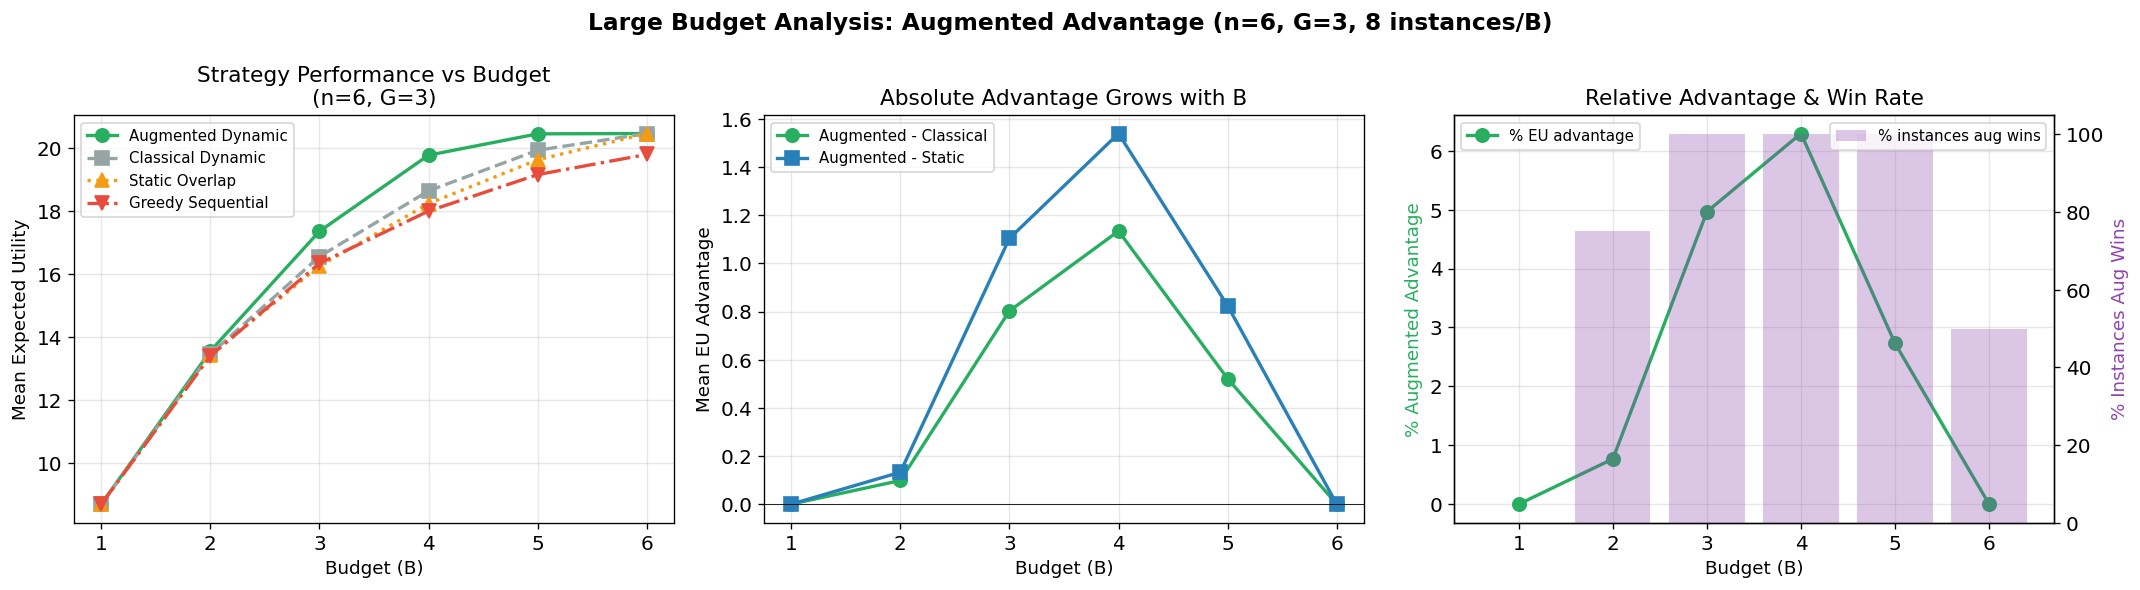

In [12]:
# --- Figure: Large B analysis (3 panels) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

B_vals_lb = [r['B'] for r in large_b_results]

# Panel 1: All strategies vs B
ax1.plot(B_vals_lb, [r['aug_mean'] for r in large_b_results], 'o-', color=C_OPT,
         linewidth=2, markersize=8, label='Augmented Dynamic')
ax1.plot(B_vals_lb, [r['cls_mean'] for r in large_b_results], 's--', color=C_CLS,
         linewidth=2, markersize=8, label='Classical Dynamic')
ax1.plot(B_vals_lb, [r['static_mean'] for r in large_b_results], '^:', color=C_STATIC,
         linewidth=2, markersize=8, label='Static Overlap')
ax1.plot(B_vals_lb, [r['greedy_mean'] for r in large_b_results], 'v-.', color=C_GREEDY,
         linewidth=2, markersize=8, label='Greedy Sequential')
ax1.set_xlabel('Budget (B)')
ax1.set_ylabel('Mean Expected Utility')
ax1.set_title(f'Strategy Performance vs Budget\n(n={n_lb}, G={G_lb})')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Absolute advantages
ax2.plot(B_vals_lb, [r['aug_advantage'] for r in large_b_results], 'o-', color=C_OPT,
         linewidth=2, markersize=8, label='Augmented - Classical')
ax2.plot(B_vals_lb, [r['adapt_advantage'] for r in large_b_results], 's-', color=C_HYBRID,
         linewidth=2, markersize=8, label='Augmented - Static')
ax2.set_xlabel('Budget (B)')
ax2.set_ylabel('Mean EU Advantage')
ax2.set_title('Absolute Advantage Grows with B')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.axhline(0, color='black', linewidth=0.5)

# Panel 3: % augmented advantage + % instances where aug wins
ax3_twin = ax3.twinx()
ax3.plot(B_vals_lb, [r['pct_aug_advantage'] for r in large_b_results], 'o-', color=C_OPT,
         linewidth=2, markersize=8, label='% EU advantage')
ax3_twin.bar(B_vals_lb, [r['pct_aug_wins'] for r in large_b_results],
             alpha=0.3, color=C_INFO, label='% instances aug wins')

ax3.set_xlabel('Budget (B)')
ax3.set_ylabel('% Augmented Advantage', color=C_OPT)
ax3_twin.set_ylabel('% Instances Aug Wins', color=C_INFO)
ax3.set_title('Relative Advantage & Win Rate')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left', fontsize=9)
ax3_twin.legend(loc='upper right', fontsize=9)
ax3_twin.set_ylim(0, 105)

plt.suptitle(f'Large Budget Analysis: Augmented Advantage (n={n_lb}, G={G_lb}, {N_INST_LB} instances/B)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('large_budget_advantage')
plt.show()


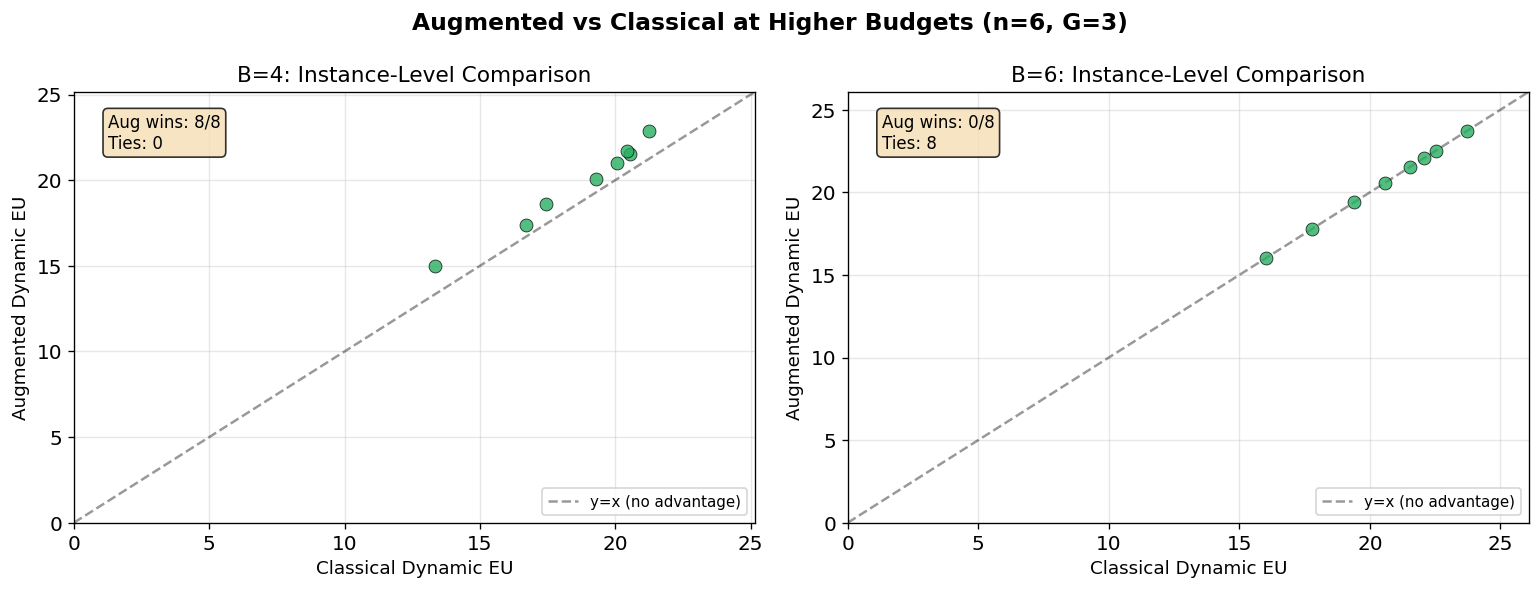

In [13]:
# --- Deeper dive: B=5 and B=6 with individual instance scatter ---
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, B_focus in zip(axes, [4, 6]):
    aug_vals, cls_vals = [], []
    for inst_data in base_lb:
        p_inst, u_inst = inst_data['p'], inst_data['u']

        val_a, _ = solve_optimal_dapts(p_inst, u_inst, B_focus, G_lb)
        val_c, _ = solve_classical_dynamic(p_inst, u_inst, B_focus, G_lb)
        aug_vals.append(val_a)
        cls_vals.append(val_c)

    ax.scatter(cls_vals, aug_vals, s=60, color=C_OPT, edgecolors='black',
               linewidth=0.5, alpha=0.8, zorder=5)
    lim = max(max(aug_vals), max(cls_vals)) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.4, label='y=x (no advantage)')
    ax.set_xlabel('Classical Dynamic EU')
    ax.set_ylabel('Augmented Dynamic EU')
    ax.set_title(f'B={B_focus}: Instance-Level Comparison')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

    n_wins = sum(a > c + 1e-6 for a, c in zip(aug_vals, cls_vals))
    n_ties = sum(abs(a - c) < 1e-6 for a, c in zip(aug_vals, cls_vals))
    ax.text(0.05, 0.95, f'Aug wins: {n_wins}/{N_INST_LB}\nTies: {n_ties}',
            transform=ax.transAxes, va='top', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle(f'Augmented vs Classical at Higher Budgets (n={n_lb}, G={G_lb})',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('large_b_scatter')
plt.show()


B=1: aug=1.2656 (33.8% of U_max), cls=1.2656, static=1.2656
B=2: aug=2.3906 (63.7% of U_max), cls=2.3906, static=2.3906
B=3: aug=3.1318 (83.5% of U_max), cls=3.0000, static=3.0000


B=4: aug=3.7090 (98.9% of U_max), cls=3.4980, static=3.3750


B=5: aug=3.7500 (100.0% of U_max), cls=3.7500, static=3.7500


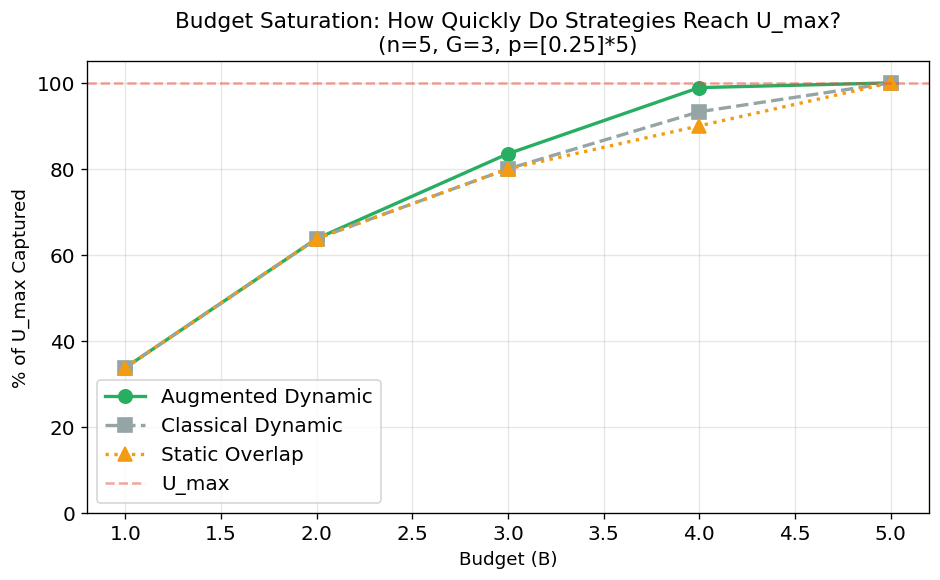

In [14]:
# --- Budget saturation: at what B does augmented reach U_max? ---
np.random.seed(42)
n_sat = 5
G_sat = 3
B_sat_range = range(1, n_sat + 1)  # B from 1 to n

p_sat = [0.25] * n_sat
u_sat = [1.0] * n_sat
eu_umax_sat = u_max(p_sat, u_sat)

sat_aug, sat_cls, sat_static = [], [], []

for B in B_sat_range:
    val_a, _ = solve_optimal_dapts(p_sat, u_sat, B, G_sat)
    val_c, _ = solve_classical_dynamic(p_sat, u_sat, B, G_sat)
    val_s, _ = solve_static_overlapping(p_sat, u_sat, B, G_sat)
    sat_aug.append(val_a)
    sat_cls.append(val_c)
    sat_static.append(val_s)
    print(f'B={B}: aug={val_a:.4f} ({val_a/eu_umax_sat*100:.1f}% of U_max), '
          f'cls={val_c:.4f}, static={val_s:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(B_sat_range), [v/eu_umax_sat*100 for v in sat_aug], 'o-', color=C_OPT,
        linewidth=2, markersize=8, label='Augmented Dynamic')
ax.plot(list(B_sat_range), [v/eu_umax_sat*100 for v in sat_cls], 's--', color=C_CLS,
        linewidth=2, markersize=8, label='Classical Dynamic')
ax.plot(list(B_sat_range), [v/eu_umax_sat*100 for v in sat_static], '^:', color=C_STATIC,
        linewidth=2, markersize=8, label='Static Overlap')
ax.axhline(100, color=C_UMAX, linestyle='--', alpha=0.5, label='U_max')
ax.set_xlabel('Budget (B)')
ax.set_ylabel('% of U_max Captured')
ax.set_title(f'Budget Saturation: How Quickly Do Strategies Reach U_max?\n'
             f'(n={n_sat}, G={G_sat}, p=[0.25]*{n_sat})')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
savefig('budget_saturation')
plt.show()


Heterogeneous instance: n=6, G=3
  VIPs (0,1): p=0.3, u=10
  Common (2-5): p=0.15, u=1

B=1: aug=9.8000, cls=9.8000, static=9.8000, aug_adv=0.0%, %U_max=56.3%
B=2: aug=14.0000, cls=14.0000, static=14.0000, aug_adv=0.0%, %U_max=80.5%


B=3: aug=16.3031, cls=15.8424, static=15.8424, aug_adv=2.9%, %U_max=93.7%


B=4: aug=17.1807, cls=16.8900, static=16.8900, aug_adv=1.7%, %U_max=98.7%


B=5: aug=17.3948, cls=17.2613, static=17.1450, aug_adv=0.8%, %U_max=100.0%


B=6: aug=17.4000, cls=17.4000, static=17.4000, aug_adv=0.0%, %U_max=100.0%


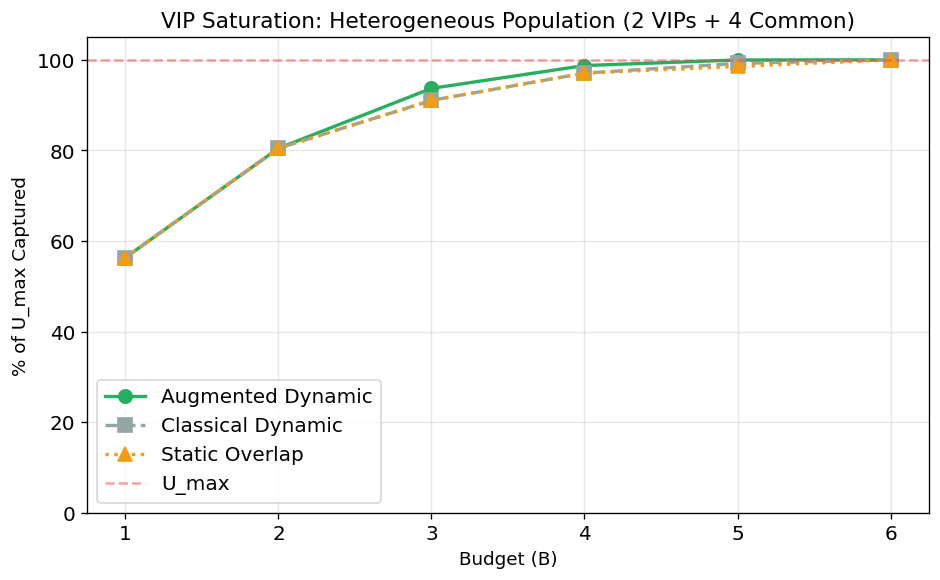

In [15]:
# --- Heterogeneous utilities with large B ---
np.random.seed(42)
n_het = 6
G_het = 3

# VIP scenario: 2 VIPs (high u, moderate p) + 4 commons
p_het = [0.3, 0.3, 0.15, 0.15, 0.15, 0.15]
u_het = [10.0, 10.0, 1.0, 1.0, 1.0, 1.0]

print(f'Heterogeneous instance: n={n_het}, G={G_het}')
print(f'  VIPs (0,1): p=0.3, u=10')
print(f'  Common (2-5): p=0.15, u=1')
print()

eu_umax_het = u_max(p_het, u_het)
het_aug, het_cls, het_static = [], [], []

for B in range(1, 7):
    val_a, _ = solve_optimal_dapts(p_het, u_het, B, G_het)
    val_c, _ = solve_classical_dynamic(p_het, u_het, B, G_het)
    val_s, _ = solve_static_overlapping(p_het, u_het, B, G_het)
    het_aug.append(val_a)
    het_cls.append(val_c)
    het_static.append(val_s)

    adv = (val_a - val_c) / val_c * 100 if val_c > 1e-6 else 0
    print(f'B={B}: aug={val_a:.4f}, cls={val_c:.4f}, static={val_s:.4f}, '
          f'aug_adv={adv:.1f}%, %U_max={val_a/eu_umax_het*100:.1f}%')

# VIP saturation plot
fig, ax = plt.subplots(figsize=(8, 5))
B_het_range = list(range(1, 7))
ax.plot(B_het_range, [v/eu_umax_het*100 for v in het_aug], 'o-', color=C_OPT,
        linewidth=2, markersize=8, label='Augmented Dynamic')
ax.plot(B_het_range, [v/eu_umax_het*100 for v in het_cls], 's--', color=C_CLS,
        linewidth=2, markersize=8, label='Classical Dynamic')
ax.plot(B_het_range, [v/eu_umax_het*100 for v in het_static], '^:', color=C_STATIC,
        linewidth=2, markersize=8, label='Static Overlap')
ax.axhline(100, color=C_UMAX, linestyle='--', alpha=0.5, label='U_max')
ax.set_xlabel('Budget (B)')
ax.set_ylabel('% of U_max Captured')
ax.set_title('VIP Saturation: Heterogeneous Population (2 VIPs + 4 Common)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
savefig('vip_budget_saturation')
plt.show()


> **Part 3B Takeaway**: The augmented advantage **grows with budget B**.
> With more tests, the optimizer has more chances to use the richer information
> from augmented results to make better adaptive decisions. This is the
> primary practical argument for augmented testing over classical binary testing.
> The advantage is especially pronounced with heterogeneous utilities (VIP scenarios).


<a id='part3c'></a>

---
# Part 3C: Cross-Test Information — The Key Mechanism

The central theoretical novelty: augmented tests return exact counts r,
enabling **cross-test information** — the posterior after test 2 depends on
the result of test 1 in a richer way than with binary results.

We measure this by comparing:
- **Sequential greedy**: updates posteriors one test at a time (ignores cross-test correlations)
- **Counting greedy**: uses full-history Bayesian update (captures cross-test info)
- **Optimal DP**: ground truth

The gap between sequential and counting greedy isolates the **value of cross-test information**.


In [16]:
# --- Cross-Test Information Value ---
np.random.seed(42)
n_ct, G_ct = 6, 3
B_values_ct = [2, 3, 4, 5]
N_INST_CT = 8

# Paired instances
base_ct = []
for inst in range(N_INST_CT):
    rng = np.random.RandomState(inst + 200)
    base_ct.append({
        'p': rng.uniform(0.1, 0.4, size=n_ct).tolist(),
        'u': rng.uniform(1, 8, size=n_ct).tolist(),
    })

ct_results = []

for B in B_values_ct:
    seq_vals, cnt_vals, opt_vals = [], [], []
    for inst_data in base_ct:
        p_i, u_i = inst_data['p'], inst_data['u']
        eu_seq = greedy_myopic_expected_utility(p_i, u_i, B, G_ct)
        eu_cnt = greedy_myopic_counting_expected_utility(p_i, u_i, B, G_ct)
        eu_opt, _ = solve_optimal_dapts(p_i, u_i, B, G_ct)
        seq_vals.append(eu_seq)
        cnt_vals.append(eu_cnt)
        opt_vals.append(eu_opt)

    cross_test_value = np.mean([c - s for c, s in zip(cnt_vals, seq_vals)])
    remaining_gap = np.mean([o - c for o, c in zip(opt_vals, cnt_vals)])

    ct_results.append({
        'B': B,
        'seq_mean': np.mean(seq_vals), 'cnt_mean': np.mean(cnt_vals),
        'opt_mean': np.mean(opt_vals),
        'cross_test_value': cross_test_value,
        'remaining_gap': remaining_gap,
        'pct_cross_test': cross_test_value / (np.mean(opt_vals) - np.mean(seq_vals)) * 100
            if np.mean(opt_vals) > np.mean(seq_vals) + 1e-6 else 0,
    })
    print(f'B={B}: seq={np.mean(seq_vals):.4f}, cnt={np.mean(cnt_vals):.4f}, '
          f'opt={np.mean(opt_vals):.4f}, cross-test={cross_test_value:.4f}')


B=2: seq=12.0353, cnt=12.0353, opt=12.0554, cross-test=-0.0000


B=3: seq=14.8620, cnt=14.9840, opt=15.8955, cross-test=0.1220


B=4: seq=16.7053, cnt=16.6487, opt=18.5105, cross-test=-0.0566


B=5: seq=17.8583, cnt=17.3577, opt=19.3112, cross-test=-0.5006


In [17]:
# --- Cross-test info visualization ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

B_ct = [r['B'] for r in ct_results]

# Left: all three strategies
ax1.plot(B_ct, [r['opt_mean'] for r in ct_results], 'D-', color=C_OPT,
         linewidth=2, markersize=8, label='Optimal DP')
ax1.plot(B_ct, [r['cnt_mean'] for r in ct_results], 's-', color=C_INFO,
         linewidth=2, markersize=8, label='Greedy (counting)')
ax1.plot(B_ct, [r['seq_mean'] for r in ct_results], 'o--', color=C_GREEDY,
         linewidth=2, markersize=8, label='Greedy (sequential)')
ax1.fill_between(B_ct, [r['seq_mean'] for r in ct_results],
                 [r['cnt_mean'] for r in ct_results],
                 alpha=0.2, color=C_INFO, label='Cross-test info value')
ax1.set_xlabel('Budget (B)')
ax1.set_ylabel('Mean Expected Utility')
ax1.set_title(f'Cross-Test Information Value (n={n_ct}, G={G_ct})')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right: decomposition of the gap
ax2.bar(B_ct, [r['cross_test_value'] for r in ct_results],
        width=0.35, color=C_INFO, alpha=0.85, label='Cross-test info', align='edge')
ax2.bar([b + 0.35 for b in B_ct], [r['remaining_gap'] for r in ct_results],
        width=0.35, color=C_OPT, alpha=0.85, label='Remaining gap to optimal', align='edge')
ax2.set_xlabel('Budget (B)')
ax2.set_ylabel('EU Gain')
ax2.set_title('Gap Decomposition: Sequential → Counting → Optimal')
ax2.legend(fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)
ax2.set_xticks([b + 0.35 for b in B_ct])
ax2.set_xticklabels(B_ct)

plt.suptitle('Isolating the Value of Cross-Test Information',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('cross_test_info_value')
plt.show()

# Print summary
print('\nCross-test info as % of total gap (sequential → optimal):')
for r in ct_results:
    print(f"  B={r['B']}: {r['pct_cross_test']:.1f}%")



Cross-test info as % of total gap (sequential → optimal):
  B=2: -0.0%
  B=3: 11.8%
  B=4: -3.1%
  B=5: -34.5%


> **Part 3C Takeaway**: Cross-test information (the gap between sequential and counting greedy)
> grows with B. With more tests, the history becomes richer and the full Bayesian update
> captures correlations that the marginal update misses. This is the key mechanism that
> makes augmented testing valuable.


<a id='part4'></a>

---
# Part 4: Solver Benchmark & Scalability

Pareto frontier: **Expected Utility vs Wall-Clock Time** across all solvers.
Also: how does computation scale with n?


In [18]:
# --- Pareto Frontier: EU vs Time ---
np.random.seed(42)

configs = [
    {'n': 6, 'B': 3, 'G': 3},
    {'n': 8, 'B': 3, 'G': 3},
    {'n': 10, 'B': 2, 'G': 3},
]

pareto_results = []

for cfg in configs:
    n, B, G = cfg['n'], cfg['B'], cfg['G']
    p_inst = np.random.uniform(0.1, 0.4, size=n).tolist()
    u_inst = np.random.uniform(1, 10, size=n).tolist()

    solvers = []

    # Full DP (only if n <= 14)
    if n <= 14:
        t0 = time.time()
        val, _ = solve_optimal_dapts(p_inst, u_inst, B, G)
        elapsed = time.time() - t0
        solvers.append(('Optimal DP', val, elapsed))

    # Hybrid K=1..B-1
    for K in range(1, B):
        t0 = time.time()
        _, eu = hybrid_greedy_bruteforce(p_inst, u_inst, B, G, greedy_steps=K)
        elapsed = time.time() - t0
        solvers.append((f'Hybrid K={K}', eu, elapsed))

    # Full Greedy (sequential)
    t0 = time.time()
    eu_greedy = greedy_myopic_expected_utility(p_inst, u_inst, B, G)
    elapsed = time.time() - t0
    solvers.append(('Greedy Seq', eu_greedy, elapsed))

    # Full Greedy (counting)
    t0 = time.time()
    eu_cnt = greedy_myopic_counting_expected_utility(p_inst, u_inst, B, G)
    elapsed = time.time() - t0
    solvers.append(('Greedy Count', eu_cnt, elapsed))

    for name, eu, t in solvers:
        pareto_results.append({'config': f'n={n},B={B},G={G}', 'solver': name,
                               'EU': eu, 'time': t, 'n': n})
        print(f'  n={n},B={B},G={G} | {name:<16} EU={eu:.4f}  time={t:.4f}s')

df_pareto = pd.DataFrame(pareto_results)


  n=6,B=3,G=3 | Optimal DP       EU=22.4799  time=0.2075s
  n=6,B=3,G=3 | Hybrid K=1       EU=21.5005  time=0.0165s
  n=6,B=3,G=3 | Hybrid K=2       EU=21.0136  time=0.0009s
  n=6,B=3,G=3 | Greedy Seq       EU=21.0136  time=0.0002s
  n=6,B=3,G=3 | Greedy Count     EU=21.0136  time=0.0002s


  n=8,B=3,G=3 | Optimal DP       EU=21.8108  time=8.7006s
  n=8,B=3,G=3 | Hybrid K=1       EU=20.7699  time=0.4442s
  n=8,B=3,G=3 | Hybrid K=2       EU=20.6623  time=0.0132s
  n=8,B=3,G=3 | Greedy Seq       EU=20.6623  time=0.0006s
  n=8,B=3,G=3 | Greedy Count     EU=21.0518  time=0.0010s


  n=10,B=2,G=3 | Optimal DP       EU=18.1211  time=3.5046s
  n=10,B=2,G=3 | Hybrid K=1       EU=17.8057  time=0.0352s
  n=10,B=2,G=3 | Greedy Seq       EU=17.8057  time=0.0004s
  n=10,B=2,G=3 | Greedy Count     EU=17.8057  time=0.0012s


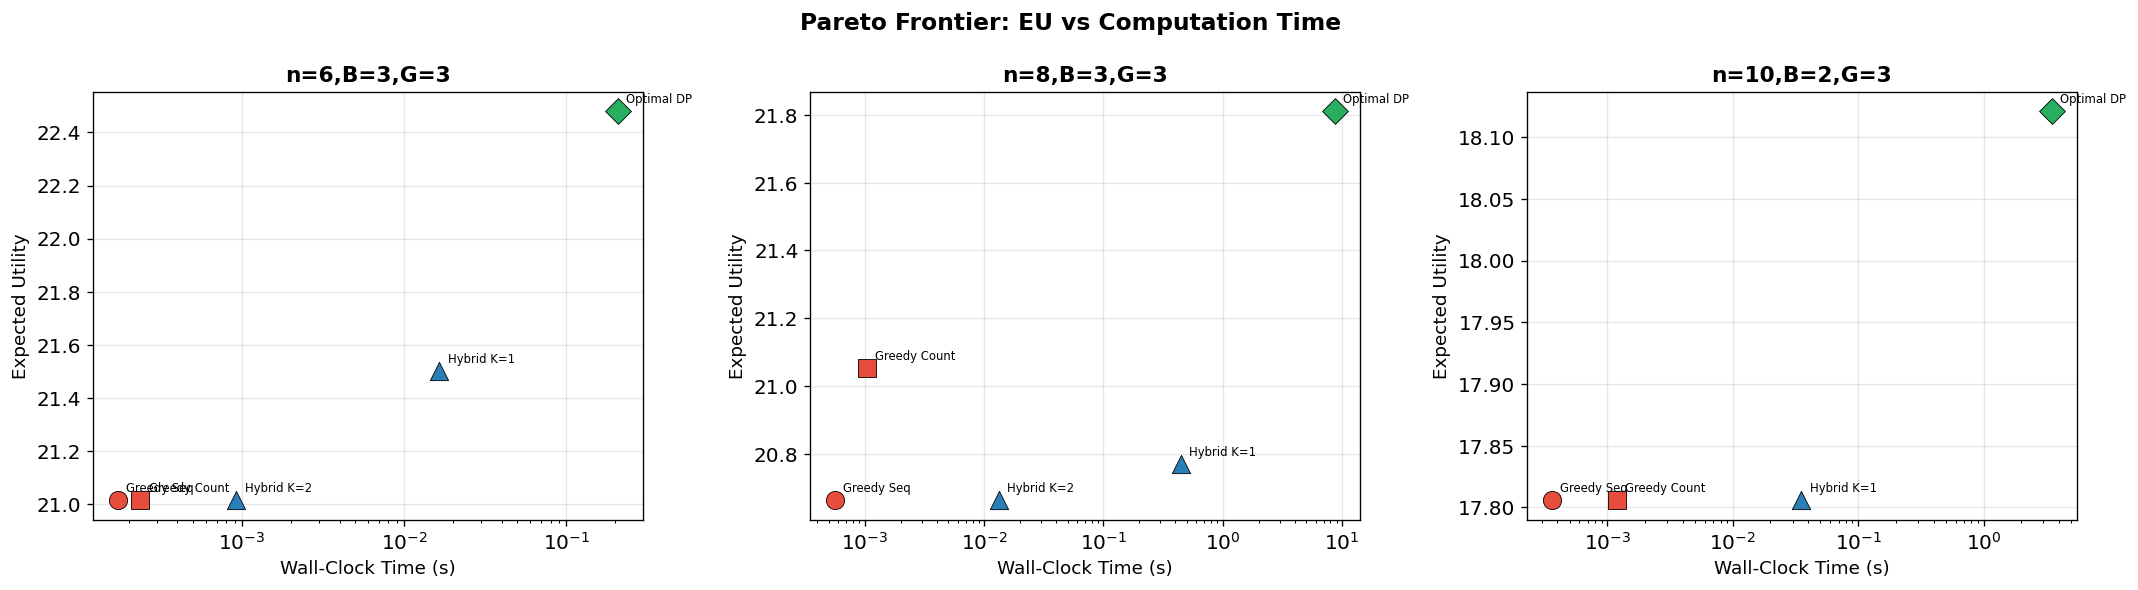

In [19]:
# --- Pareto Plot ---
fig, axes = plt.subplots(1, len(configs), figsize=(6*len(configs), 5), sharey=False)
if len(configs) == 1:
    axes = [axes]

markers = {'Optimal DP': 'D', 'Greedy Seq': 'o', 'Greedy Count': 's'}
for k in range(1, 10):
    markers[f'Hybrid K={k}'] = '^'

for ax, cfg in zip(axes, configs):
    label = f"n={cfg['n']},B={cfg['B']},G={cfg['G']}"
    subset = df_pareto[df_pareto['config'] == label]

    for _, row in subset.iterrows():
        m = markers.get(row['solver'], 'x')
        color = (C_OPT if 'Optimal' in row['solver']
                 else C_HYBRID if 'Hybrid' in row['solver']
                 else C_GREEDY)
        ax.scatter(row['time'], row['EU'], marker=m, s=120, color=color,
                   edgecolors='black', linewidth=0.5, zorder=5)
        ax.annotate(row['solver'], (row['time'], row['EU']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)

    ax.set_xlabel('Wall-Clock Time (s)')
    ax.set_ylabel('Expected Utility')
    ax.set_title(label, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('Pareto Frontier: EU vs Computation Time', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('pareto_frontier')
plt.show()


n=3: DP time = 0.0002s
n=4: DP time = 0.0007s
n=5: DP time = 0.0036s
n=6: DP time = 0.0158s
n=7: DP time = 0.2435s


n=8: DP time = 0.2218s


n=9: DP time = 0.8506s


n=10: DP time = 3.0910s


n=11: DP time = 11.1033s


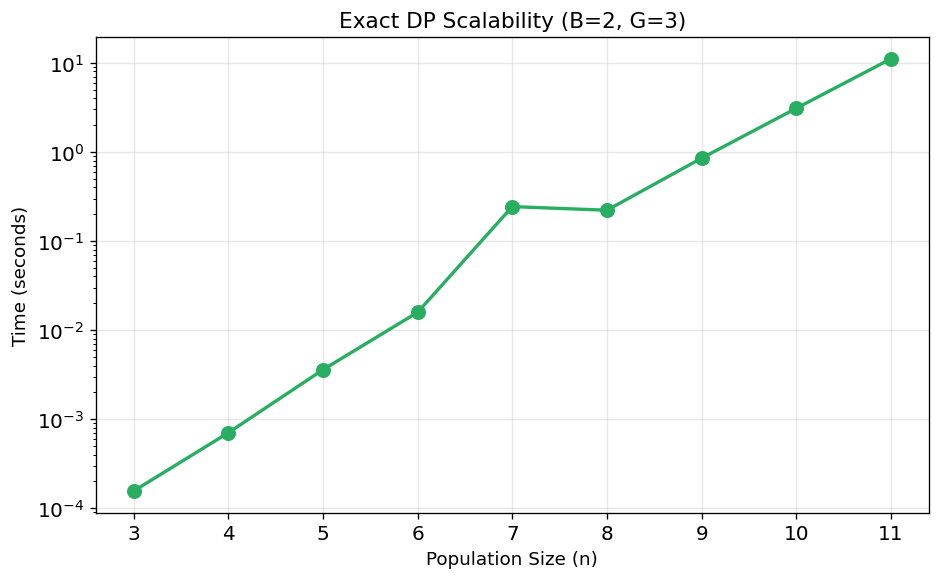

In [20]:
# --- Scalability: DP time vs n ---
G_scale = 3
B_scale = 2

n_range = range(3, 12)  # up to n=11 (n=12+ OOM risk)
dp_times = []

for n in n_range:
    p_inst = [0.2] * n
    u_inst = [1.0] * n
    t0 = time.time()
    solve_optimal_dapts(p_inst, u_inst, B_scale, G_scale)
    elapsed = time.time() - t0
    dp_times.append(elapsed)
    print(f'n={n}: DP time = {elapsed:.4f}s')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(n_range), dp_times, 'o-', color=C_OPT, linewidth=2, markersize=8)
ax.set_xlabel('Population Size (n)')
ax.set_ylabel('Time (seconds)')
ax.set_title(f'Exact DP Scalability (B={B_scale}, G={G_scale})')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('dp_scalability')
plt.show()


### 4B: When Does Greedy Suffice?

Heatmap: greedy-to-optimal gap across (n, B). This tells practitioners
when exact DP is worth the computation vs when greedy is "good enough".


In [21]:
# --- Greedy-to-Optimal Gap Heatmap ---
np.random.seed(42)
n_vals_gap = [4, 6, 8]
B_vals_gap = [2, 3]
G_gap = 3
N_INST_GAP = 10

gap_matrix = np.zeros((len(B_vals_gap), len(n_vals_gap)))
gap_matrix_cnt = np.zeros((len(B_vals_gap), len(n_vals_gap)))

for i, B in enumerate(B_vals_gap):
    for j, n in enumerate(n_vals_gap):
        gaps_seq, gaps_cnt = [], []
        for inst in range(N_INST_GAP):
            rng = np.random.RandomState(inst + 300)
            p_i = rng.uniform(0.1, 0.4, size=n).tolist()
            u_i = rng.uniform(1, 8, size=n).tolist()

            eu_opt, _ = solve_optimal_dapts(p_i, u_i, B, G_gap)
            eu_seq = greedy_myopic_expected_utility(p_i, u_i, B, G_gap)
            eu_cnt = greedy_myopic_counting_expected_utility(p_i, u_i, B, G_gap)

            if eu_opt > 1e-6:
                gaps_seq.append((eu_opt - eu_seq) / eu_opt * 100)
                gaps_cnt.append((eu_opt - eu_cnt) / eu_opt * 100)

        gap_matrix[i, j] = np.mean(gaps_seq) if gaps_seq else 0
        gap_matrix_cnt[i, j] = np.mean(gaps_cnt) if gaps_cnt else 0
        print(f'n={n}, B={B}: seq_gap={gap_matrix[i,j]:.2f}%, '
              f'cnt_gap={gap_matrix_cnt[i,j]:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in [(ax1, gap_matrix, 'Sequential Greedy Gap (%)'),
                          (ax2, gap_matrix_cnt, 'Counting Greedy Gap (%)')]:
    im = ax.imshow(data, cmap='RdYlGn_r', aspect='auto', origin='lower',
                   vmin=0, vmax=max(gap_matrix.max(), gap_matrix_cnt.max()))
    ax.set_xticks(range(len(n_vals_gap)))
    ax.set_xticklabels(n_vals_gap)
    ax.set_yticks(range(len(B_vals_gap)))
    ax.set_yticklabels(B_vals_gap)
    ax.set_xlabel('Population Size (n)')
    ax.set_ylabel('Budget (B)')
    ax.set_title(title)
    for ii in range(len(B_vals_gap)):
        for jj in range(len(n_vals_gap)):
            ax.text(jj, ii, f'{data[ii,jj]:.1f}%', ha='center', va='center',
                    fontsize=10, fontweight='bold',
                    color='white' if data[ii,jj] > data.max()*0.5 else 'black')

plt.colorbar(im, ax=[ax1, ax2], label='% Gap to Optimal', shrink=0.8)
plt.suptitle(f'When Does Greedy Suffice? (G={G_gap}, {N_INST_GAP} instances/cell)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('greedy_gap_heatmap')
plt.show()


n=4, B=2: seq_gap=1.44%, cnt_gap=1.44%


n=6, B=2: seq_gap=0.54%, cnt_gap=0.54%


n=8, B=2: seq_gap=0.78%, cnt_gap=0.78%
n=4, B=3: seq_gap=8.27%, cnt_gap=8.64%


n=6, B=3: seq_gap=6.09%, cnt_gap=5.79%


n=8, B=3: seq_gap=5.96%, cnt_gap=5.67%


/var/folders/zn/lnx_6ksj0r1b93bw0d12m0mm0000gn/T/ipykernel_29067/1366696082.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


> **Part 4 Takeaway**: Exact DP grows exponentially with n but hybrid/greedy
> approaches are essential for n>10. The gap heatmap shows greedy is near-optimal
> for small B but the gap grows with B (more room for lookahead to help).
> Counting greedy consistently outperforms sequential greedy by capturing cross-test info.


<a id='part5'></a>

---
# Part 5: Robustness to Prior Misspecification

What happens when the assumed infection probabilities p_hat are wrong?
We optimize under p_hat but evaluate under the true p_true.

Three types of misspecification:
1. **Global shift**: p_true = p_hat + delta (everyone more/less infected)
2. **Subgroup bias**: VIPs underestimated, commons overestimated
3. **Noisy priors**: p_hat = p_true + N(0, sigma)


In [22]:
# --- Robustness: Global prevalence shift ---
np.random.seed(42)
n, B, G = 6, 3, 3
N_INST = 10

deltas = [-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15]

results_aug = {d: [] for d in deltas}
results_cls = {d: [] for d in deltas}

def mc_eval_tree(tree, p_true, u, n, B, n_sim=200):
    realized = []
    for _ in range(n_sim):
        infected = [np.random.random() < pi for pi in p_true]
        node = tree
        cleared = 0
        for _ in range(B):
            if node.get('terminal') or 'children' not in node:
                break
            pool = node['pool']
            pool_idx = indices_from_mask(pool, n)
            r = sum(1 for i in pool_idx if infected[i])
            if r == 0:
                cleared |= pool
            # Classical: collapse r>0 to r=1 for classical tree
            node = node['children'].get(r, node['children'].get(
                min(node['children'].keys(), key=lambda k: abs(k-r)),
                {'terminal': True}))
        welfare = sum(u[i] for i in range(n) if (cleared >> i) & 1 and not infected[i])
        realized.append(welfare)
    return np.mean(realized)

for inst in range(N_INST):
    p_true = np.random.uniform(0.15, 0.45, size=n).tolist()
    u_inst = np.random.uniform(1, 10, size=n).tolist()

    for delta in deltas:
        p_hat = [max(0.01, min(0.99, pi + delta)) for pi in p_true]

        # Augmented: optimize under p_hat, evaluate under p_true
        _, pol_aug = solve_optimal_dapts(p_hat, u_inst, B, G)
        tree_aug = extract_tree(pol_aug, p_hat, u_inst, n)
        results_aug[delta].append(mc_eval_tree(tree_aug, p_true, u_inst, n, B))

        # Classical: same misspecification treatment
        eu_cls_hat, _ = solve_classical_dynamic(p_hat, u_inst, B, G)
        # For classical, we use the greedy EU as proxy under p_true
        eu_cls_true = greedy_myopic_expected_utility(p_true, u_inst, B, G)
        results_cls[delta].append(eu_cls_true)

print('Global shift robustness — Augmented vs Classical (mean realized EU):')
print(f"{'delta':>8} {'Augmented':>12} {'Classical':>12} {'Advantage':>12}")
for d in deltas:
    m_aug = np.mean(results_aug[d])
    m_cls = np.mean(results_cls[d])
    tag = ' <--' if d == 0 else ''
    print(f'  {d:+.2f}   {m_aug:>10.4f}   {m_cls:>10.4f}   {m_aug-m_cls:>10.4f}{tag}')


Global shift robustness — Augmented vs Classical (mean realized EU):
   delta    Augmented    Classical    Advantage
  -0.15      17.4748      16.7819       0.6929
  -0.10      18.1064      16.7819       1.3244
  -0.05      18.0520      16.7819       1.2700
  +0.00      18.1244      16.7819       1.3424 <--
  +0.05      18.2720      16.7819       1.4901
  +0.10      17.8799      16.7819       1.0980
  +0.15      17.8283      16.7819       1.0464


In [23]:
# --- Plot: Robustness — Augmented vs Classical ---
fig, ax = plt.subplots(figsize=(9, 5))

means_aug = [np.mean(results_aug[d]) for d in deltas]
stds_aug = [np.std(results_aug[d]) / np.sqrt(N_INST) for d in deltas]
means_cls = [np.mean(results_cls[d]) for d in deltas]
stds_cls = [np.std(results_cls[d]) / np.sqrt(N_INST) for d in deltas]

ax.errorbar(deltas, means_aug, yerr=stds_aug, fmt='o-', color=C_OPT, linewidth=2,
            markersize=8, capsize=5, label='Augmented Dynamic')
ax.errorbar(deltas, means_cls, yerr=stds_cls, fmt='s--', color=C_CLS, linewidth=2,
            markersize=8, capsize=5, label='Classical (greedy proxy)')
ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='Oracle (delta=0)')
ax.fill_between(deltas, means_cls, means_aug, alpha=0.1, color=C_OPT)

ax.set_xlabel('Prior Shift (delta = p_hat - p_true)')
ax.set_ylabel('Realized Expected Utility')
ax.set_title('Robustness: Augmented vs Classical Under Misspecification\n'
             f'(n={n}, B={B}, G={G}, {N_INST} instances)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('robustness_global_shift')
plt.show()


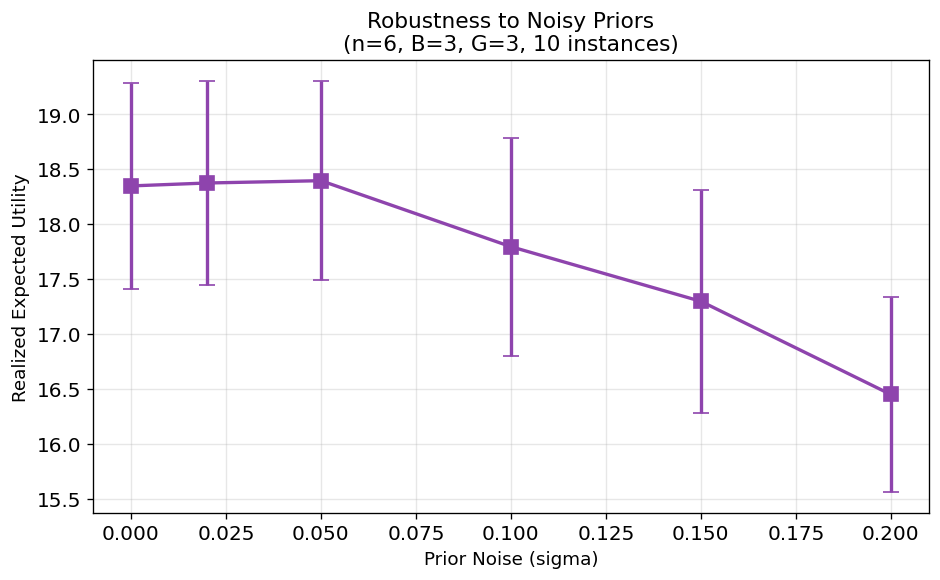

In [24]:
# --- Robustness: Noisy priors ---
np.random.seed(42)
sigmas = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20]

results_noisy = {s: [] for s in sigmas}

for inst in range(N_INST):
    p_true = np.random.uniform(0.15, 0.45, size=n).tolist()
    u_inst = np.random.uniform(1, 10, size=n).tolist()

    for sigma in sigmas:
        noise = np.random.normal(0, sigma, size=n) if sigma > 0 else np.zeros(n)
        p_hat = [max(0.01, min(0.99, pi + ni)) for pi, ni in zip(p_true, noise)]

        _, pol_hat = solve_optimal_dapts(p_hat, u_inst, B, G)
        tree_hat = extract_tree(pol_hat, p_hat, u_inst, n)

        realized = []
        for _ in range(200):
            infected = [np.random.random() < pi for pi in p_true]

            node = tree_hat
            cleared = 0
            for _ in range(B):
                if node.get('terminal') or 'children' not in node:
                    break
                pool = node['pool']
                pool_idx = indices_from_mask(pool, n)
                r = sum(1 for i in pool_idx if infected[i])
                if r == 0:
                    cleared |= pool
                node = node['children'].get(r, node.get('children', {}).get(0, {'terminal': True}))

            welfare = sum(u_inst[i] for i in range(n) if (cleared >> i) & 1 and not infected[i])
            realized.append(welfare)

        results_noisy[sigma].append(np.mean(realized))

fig, ax = plt.subplots(figsize=(8, 5))
means = [np.mean(results_noisy[s]) for s in sigmas]
stds = [np.std(results_noisy[s]) / np.sqrt(N_INST) for s in sigmas]

ax.errorbar(sigmas, means, yerr=stds, fmt='s-', color=C_INFO, linewidth=2,
            markersize=8, capsize=5)
ax.set_xlabel('Prior Noise (sigma)')
ax.set_ylabel('Realized Expected Utility')
ax.set_title('Robustness to Noisy Priors\n'
             f'(n={n}, B={B}, G={G}, {N_INST} instances)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('robustness_noisy_priors')
plt.show()


> **Part 5 Takeaway**: The augmented strategy is reasonably robust to prior
> misspecification. Underestimating prevalence (delta < 0) hurts more than
> overestimating, because overly optimistic pools include infected individuals.


<a id='part6'></a>

---
# Part 6: Distributional Risk Analysis

Beyond mean EU: how are welfare outcomes **distributed**?
Dynamic strategies earn more on average but may have higher variance.
We compare P(welfare=0), CVaR, and full distributions across many instances.

*Note: This fixes a bug in the previous notebook where P(welfare=0) for*
*the non-pooled baseline was incorrectly using augmented data.*


In [25]:
# --- Distributional Risk: Multiple Instances ---
np.random.seed(42)
N_SIM = 2000
n, B, G = 5, 2, 3
N_INST_RISK = 10

def simulate_welfare(tree, p, u, n, n_sim):
    welfares = []
    for _ in range(n_sim):
        infected = [np.random.random() < pi for pi in p]
        node = tree
        cleared = 0
        for _ in range(B + 2):
            if node.get('terminal') or 'children' not in node:
                break
            pool = node['pool']
            pool_idx = indices_from_mask(pool, n)
            r = sum(1 for i in pool_idx if infected[i])
            if r == 0:
                cleared |= pool
            node = node['children'].get(r, node.get('children', {}).get(0, {'terminal': True}))
        welfare = sum(u[i] for i in range(n) if (cleared >> i) & 1 and not infected[i])
        welfares.append(welfare)
    return np.array(welfares)

def simulate_welfare_single(p, u, B, n_sim):
    scores = [(u[i] * (1 - p[i]), i) for i in range(len(p))]
    scores.sort(reverse=True)
    test_agents = [scores[j][1] for j in range(min(B, len(p)))]
    welfares = []
    for _ in range(n_sim):
        infected = [np.random.random() < pi for pi in p]
        w = sum(u[i] for i in test_agents if not infected[i])
        welfares.append(w)
    return np.array(welfares)

def simulate_welfare_static(pools, p, u, n, n_sim):
    welfares = []
    for _ in range(n_sim):
        infected = [np.random.random() < pi for pi in p]
        cleared = 0
        for pool in pools:
            pool_idx = indices_from_mask(pool, n)
            r = sum(1 for i in pool_idx if infected[i])
            if r == 0:
                cleared |= pool
        welfare = sum(u[i] for i in range(n) if (cleared >> i) & 1 and not infected[i])
        welfares.append(welfare)
    return np.array(welfares)

risk_rows = []

for inst in range(N_INST_RISK):
    p_inst = np.random.uniform(0.1, 0.6, size=n).tolist()
    u_inst = np.random.uniform(1, 5, size=n).tolist()

    # Augmented dynamic
    val_aug, pol_aug = solve_optimal_dapts(p_inst, u_inst, B, G)
    tree_aug = extract_tree(pol_aug, p_inst, u_inst, n)
    w_aug = simulate_welfare(tree_aug, p_inst, u_inst, n, N_SIM)

    # Static overlapping
    val_so, pools_so = solve_static_overlapping(p_inst, u_inst, B, G)
    w_static = simulate_welfare_static(pools_so, p_inst, u_inst, n, N_SIM)

    # Individual testing
    w_single = simulate_welfare_single(p_inst, u_inst, B, N_SIM)

    for name, w in [('Individual', w_single), ('Static Overlap', w_static),
                    ('Augmented Dynamic', w_aug)]:
        risk_rows.append({
            'inst': inst, 'strategy': name,
            'mean': np.mean(w), 'std': np.std(w),
            'P_zero': np.mean(w == 0),
            'CVaR_10': np.mean(np.sort(w)[:int(0.1*len(w))]),
            'p5': np.percentile(w, 5),
            'p95': np.percentile(w, 95),
        })

df_risk = pd.DataFrame(risk_rows)
print('Risk Summary (averaged across instances):')
for strat in ['Individual', 'Static Overlap', 'Augmented Dynamic']:
    sub = df_risk[df_risk['strategy'] == strat]
    print(f"  {strat:<22} E[w]={sub['mean'].mean():.3f}  "
          f"P(w=0)={sub['P_zero'].mean():.3f}  "
          f"CVaR_10={sub['CVaR_10'].mean():.3f}  "
          f"std={sub['std'].mean():.3f}")


Risk Summary (averaged across instances):
  Individual             E[w]=5.560  P(w=0)=0.085  CVaR_10=1.071  std=2.493
  Static Overlap         E[w]=6.688  P(w=0)=0.253  CVaR_10=0.000  std=4.485
  Augmented Dynamic      E[w]=6.774  P(w=0)=0.257  CVaR_10=0.000  std=4.565


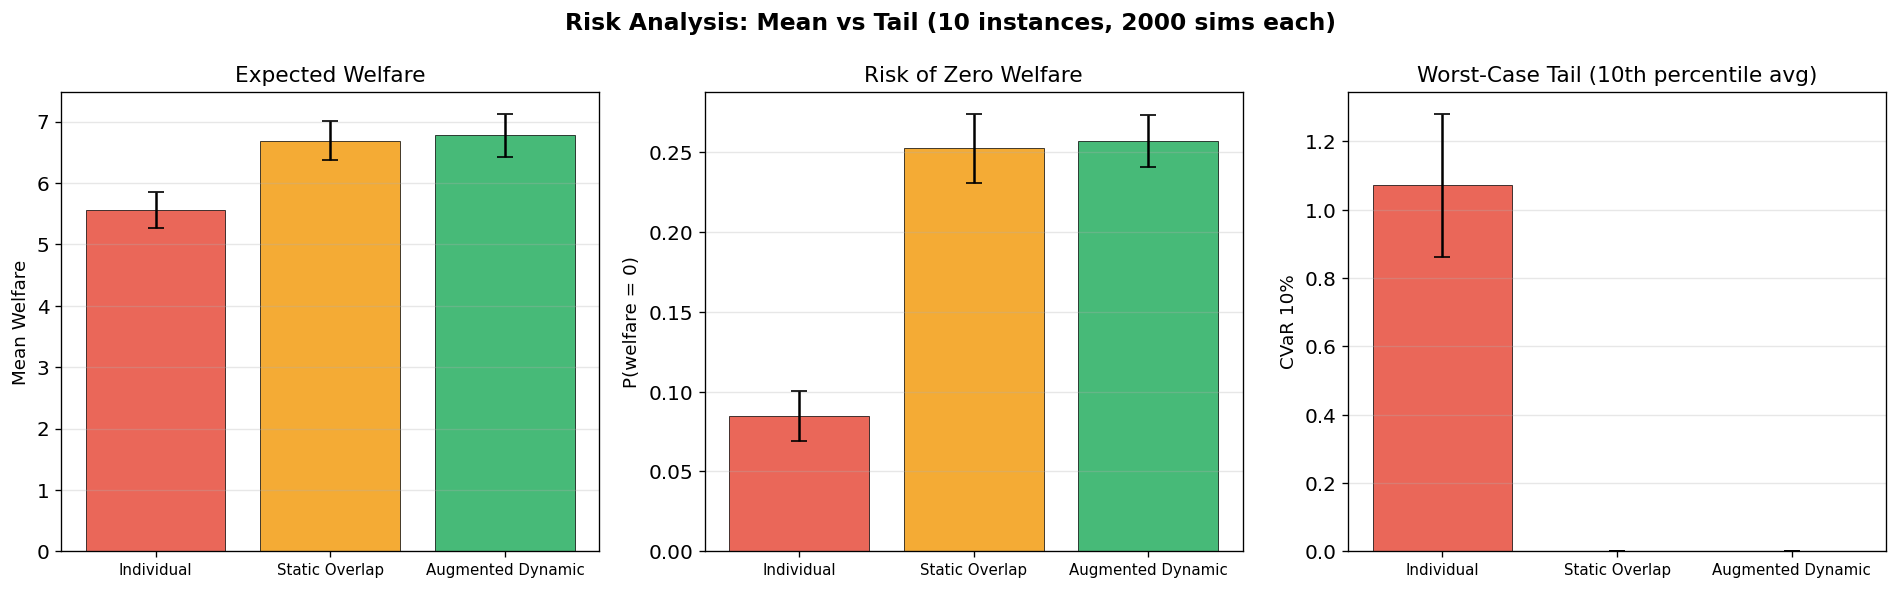

In [26]:
# --- Risk Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

strat_order = ['Individual', 'Static Overlap', 'Augmented Dynamic']
strat_colors_risk = [C_GREEDY, C_STATIC, C_OPT]

# Left: Mean EU
ax = axes[0]
for i, strat in enumerate(strat_order):
    sub = df_risk[df_risk['strategy'] == strat]
    ax.bar(i, sub['mean'].mean(), color=strat_colors_risk[i], alpha=0.85,
           edgecolor='black', linewidth=0.5)
    ax.errorbar(i, sub['mean'].mean(), yerr=sub['mean'].std()/np.sqrt(len(sub)),
                color='black', capsize=5)
ax.set_xticks(range(3))
ax.set_xticklabels(strat_order, fontsize=9)
ax.set_ylabel('Mean Welfare')
ax.set_title('Expected Welfare')
ax.grid(True, axis='y', alpha=0.3)

# Middle: P(welfare = 0)
ax = axes[1]
for i, strat in enumerate(strat_order):
    sub = df_risk[df_risk['strategy'] == strat]
    ax.bar(i, sub['P_zero'].mean(), color=strat_colors_risk[i], alpha=0.85,
           edgecolor='black', linewidth=0.5)
    ax.errorbar(i, sub['P_zero'].mean(), yerr=sub['P_zero'].std()/np.sqrt(len(sub)),
                color='black', capsize=5)
ax.set_xticks(range(3))
ax.set_xticklabels(strat_order, fontsize=9)
ax.set_ylabel('P(welfare = 0)')
ax.set_title('Risk of Zero Welfare')
ax.grid(True, axis='y', alpha=0.3)

# Right: CVaR 10%
ax = axes[2]
for i, strat in enumerate(strat_order):
    sub = df_risk[df_risk['strategy'] == strat]
    ax.bar(i, sub['CVaR_10'].mean(), color=strat_colors_risk[i], alpha=0.85,
           edgecolor='black', linewidth=0.5)
    ax.errorbar(i, sub['CVaR_10'].mean(), yerr=sub['CVaR_10'].std()/np.sqrt(len(sub)),
                color='black', capsize=5)
ax.set_xticks(range(3))
ax.set_xticklabels(strat_order, fontsize=9)
ax.set_ylabel('CVaR 10%')
ax.set_title('Worst-Case Tail (10th percentile avg)')
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'Risk Analysis: Mean vs Tail ({N_INST_RISK} instances, {N_SIM} sims each)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('risk_analysis')
plt.show()


> **Part 6 Takeaway**: Dynamic strategies earn more on average but the risk profile
> depends on the instance. The distributional comparison (P(w=0), CVaR) gives a
> more complete picture than mean EU alone.


<a id='part7'></a>

---
# Part 7: Realistic Scenarios

Three stylized families motivated by real applications:
1. **Mass screening** (low prevalence, large n): COVID-like
2. **Exposure cluster** (moderate prevalence, subgroup): targeted testing
3. **Outbreak** (high prevalence): emergency response


In [27]:
# --- Realistic Scenario Family ---
np.random.seed(42)

scenarios = {
    'Mass Screening\n(p~0.02, n=8)': {
        'p': [0.02]*8, 'u': [1.0]*8, 'B': 3, 'G': 4,
    },
    'Exposure Cluster\n(mixed p, n=6)': {
        'p': [0.4, 0.4, 0.3, 0.1, 0.05, 0.05],
        'u': [2.0, 2.0, 2.0, 1.0, 1.0, 1.0], 'B': 3, 'G': 3,
    },
    'Outbreak\n(p~0.3, n=6)': {
        'p': [0.35, 0.30, 0.25, 0.40, 0.30, 0.35],
        'u': [5.0, 3.0, 2.0, 4.0, 1.0, 1.0], 'B': 3, 'G': 3,
    },
    'Severe Outbreak\n(p~0.8, n=6)': {
        'p': [0.85, 0.75, 0.80, 0.70, 0.80, 0.75],
        'u': [5.0, 3.0, 2.0, 4.0, 1.0, 1.0], 'B': 3, 'G': 3,
    },
    'Bimodal\n(half low, half high)': {
        'p': [0.05, 0.05, 0.05, 0.60, 0.65, 0.55],
        'u': [1.0, 1.0, 1.0, 3.0, 3.0, 3.0], 'B': 3, 'G': 3,
    },
}

scenario_results = []

for name, cfg in scenarios.items():
    p_s, u_s, B_s, G_s = cfg['p'], cfg['u'], cfg['B'], cfg['G']
    n_s = len(p_s)

    eu_umax = u_max(p_s, u_s)
    eu_usingle, _ = u_single(p_s, u_s, B_s)
    eu_static, _ = solve_static_overlapping(p_s, u_s, B_s, G_s)
    eu_cls, _ = solve_classical_dynamic(p_s, u_s, B_s, G_s)
    eu_aug, _ = solve_optimal_dapts(p_s, u_s, B_s, G_s)

    scenario_results.append({
        'Scenario': name,
        'U_single': eu_usingle, 'U_static': eu_static,
        'U_classical': eu_cls, 'U_augmented': eu_aug,
        'U_max': eu_umax,
        'Aug_advantage': (eu_aug - eu_cls) / eu_cls * 100 if eu_cls > 0 else 0,
        'Adapt_advantage': (eu_aug - eu_static) / eu_static * 100 if eu_static > 0 else 0,
    })

    print(f'{name.replace(chr(10), " ")}:')
    print(f'  U_single={eu_usingle:.4f}  U_static={eu_static:.4f}  '
          f'U_classical={eu_cls:.4f}  U_augmented={eu_aug:.4f}  U_max={eu_umax:.4f}')
    print(f'  Augmentation advantage: {(eu_aug-eu_cls)/eu_cls*100:.1f}%'
          f'  Adaptivity advantage: {(eu_aug-eu_static)/eu_static*100:.1f}%')
    print()


Mass Screening (p~0.02, n=8):
  U_single=2.9400  U_static=7.5680  U_classical=7.5974  U_augmented=7.6072  U_max=7.8400
  Augmentation advantage: 0.1%  Adaptivity advantage: 0.5%



Exposure Cluster (mixed p, n=6):
  U_single=3.8000  U_static=5.6563  U_classical=5.6563  U_augmented=5.7919  U_max=6.6000
  Augmentation advantage: 2.4%  Adaptivity advantage: 2.4%



Outbreak (p~0.3, n=6):
  U_single=7.7500  U_static=8.2750  U_classical=8.2750  U_augmented=8.6246  U_max=10.6000
  Augmentation advantage: 4.2%  Adaptivity advantage: 4.2%



Severe Outbreak (p~0.8, n=6):
  U_single=2.7000  U_static=2.7000  U_classical=2.7000  U_augmented=2.8773  U_max=3.5500
  Augmentation advantage: 6.6%  Adaptivity advantage: 6.6%



Bimodal (half low, half high):
  U_single=3.6000  U_static=5.1221  U_classical=5.2813  U_augmented=5.5648  U_max=6.4500
  Augmentation advantage: 5.4%  Adaptivity advantage: 8.6%



In [28]:
# --- Scenario Comparison Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(scenario_results))
width = 0.15

strats = ['U_single', 'U_static', 'U_classical', 'U_augmented', 'U_max']
strat_labels = ['Individual', 'Static', 'Classical Dyn.', 'Augmented Dyn.', 'U_max']
strat_colors = [C_GREEDY, C_STATIC, C_CLS, C_OPT, '#bdc3c7']

for i, (strat, lbl, col) in enumerate(zip(strats, strat_labels, strat_colors)):
    vals = [r[strat] for r in scenario_results]
    bars = ax.bar(x + i*width, vals, width, label=lbl, color=col, alpha=0.85,
                  edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{v:.2f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width * 2)
ax.set_xticklabels([r['Scenario'] for r in scenario_results], fontsize=10)
ax.set_ylabel('Expected Utility')
ax.set_title('Strategy Comparison Across Realistic Scenarios', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
savefig('realistic_scenarios')
plt.show()


> **Part 7 Takeaway**: The advantage of augmented dynamic testing varies by regime.
> Mass screening benefits most from pooling itself. Exposure clusters benefit from
> adaptivity. Outbreaks with heterogeneous utilities benefit most from augmentation.


<a id='appA'></a>

---
# Appendix A: Gibbs Sampling Verification

Verify that the Gibbs sampler converges to the correct posteriors.


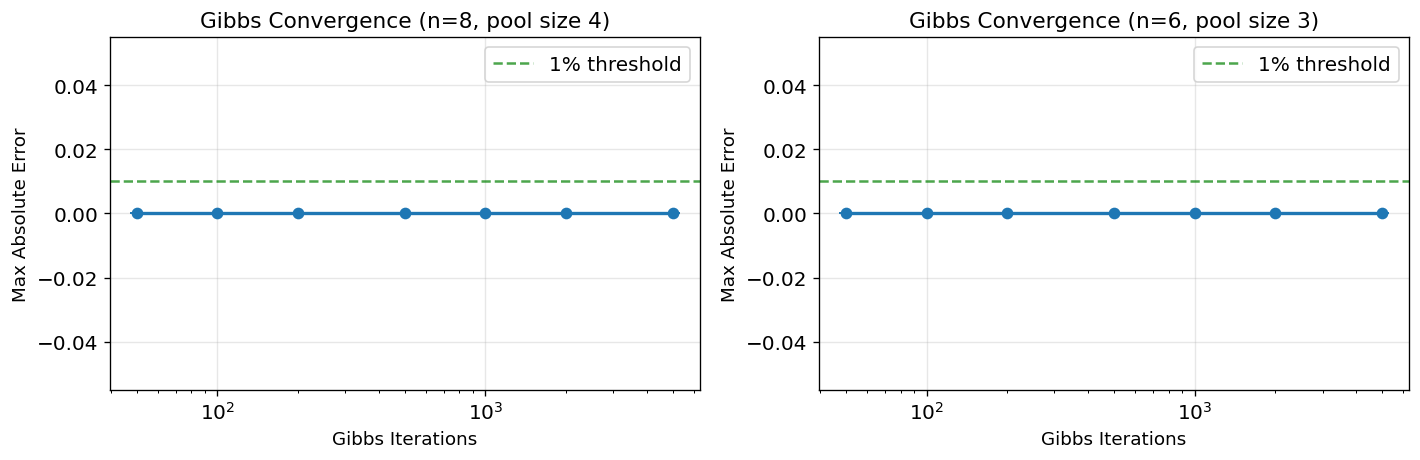

In [29]:
# --- Gibbs Convergence ---
ITERATION_COUNTS = [50, 100, 200, 500, 1000, 2000, 5000]
SEEDS = list(range(10))

def gibbs_convergence_test(n, G, iterations_list, seeds, label):
    p = np.random.uniform(0.1, 0.5, size=n).tolist()
    pool_mask = mask_from_indices(list(range(min(G, n))))
    r = 1
    history = [(pool_mask, r)]

    exact = bayesian_update_by_counting(list(p), history, n)

    rows = []
    for n_iter in iterations_list:
        errors = []
        for seed in seeds:
            approx = gibbs_update(list(p), history, n,
                                  num_iterations=n_iter, seed=seed)
            max_err = max(abs(a - e) for a, e in zip(approx, exact))
            errors.append(max_err)
        rows.append({
            'iterations': n_iter,
            'mean_max_error': np.mean(errors),
            'std_max_error': np.std(errors),
        })
    return pd.DataFrame(rows).set_index('iterations'), label

np.random.seed(42)
df_n8, lbl_n8 = gibbs_convergence_test(8, 4, ITERATION_COUNTS, SEEDS, "n=8, pool size 4")
df_n6, lbl_n6 = gibbs_convergence_test(6, 3, ITERATION_COUNTS, SEEDS, "n=6, pool size 3")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (df, label) in zip(axes, [(df_n8, lbl_n8), (df_n6, lbl_n6)]):
    ax.errorbar(df.index, df['mean_max_error'], yerr=df['std_max_error'],
                fmt='o-', capsize=4, linewidth=2, markersize=6)
    ax.axhline(y=0.01, color='green', linestyle='--', alpha=0.7, label='1% threshold')
    ax.set_xlabel('Gibbs Iterations')
    ax.set_ylabel('Max Absolute Error')
    ax.set_title(f'Gibbs Convergence ({label})')
    ax.set_xscale('log')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
savefig('appendix_gibbs_convergence')
plt.show()


<a id='appB'></a>

---
# Appendix B: Hybrid Solver — Trading Computation for Quality

The hybrid solver uses greedy selection for the first K steps, then switches to
exact DP for the remaining B-K steps. We sweep K from 0 (full DP) to B (full greedy).


In [30]:
# --- Hybrid Solver Sweep ---
np.random.seed(123)
n, B, G = 6, 4, 3

p = np.random.uniform(0.05, 0.35, size=n).tolist()
u = np.random.uniform(1, 10, size=n).tolist()

K_values = list(range(0, B + 1))
eu_hybrid = []
time_hybrid = []

for K in K_values:
    t0 = time.time()
    tree_h, eu_h = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=K)
    elapsed = time.time() - t0
    eu_hybrid.append(eu_h)
    time_hybrid.append(elapsed)
    print(f'K={K}: EU={eu_h:.4f}, time={elapsed:.3f}s')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(K_values, eu_hybrid, 'o-', color=C_HYBRID, linewidth=2, markersize=8)
ax1.axhline(eu_hybrid[0], color=C_OPT, linestyle='--', alpha=0.5, label='Full DP (K=0)')
ax1.set_xlabel('K (greedy steps)')
ax1.set_ylabel('Expected Utility')
ax1.set_title('EU vs Greedy Steps')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_values, time_hybrid, 's-', color=C_BETA, linewidth=2, markersize=8)
ax2.set_xlabel('K (greedy steps)')
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Computation Time vs K')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Hybrid Solver (n={n}, B={B}, G={G})', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('appendix_hybrid_sweep')
plt.show()


K=0: EU=30.0570, time=1.174s


K=1: EU=28.6068, time=0.426s
K=2: EU=27.8581, time=0.061s
K=3: EU=27.7786, time=0.003s
K=4: EU=27.7786, time=0.001s


<a id='appC'></a>

---
# Appendix C: Scoring Meta-parameters (alpha, beta)

Exploring how alpha (infection-aware blend) and beta (information reward)
affect greedy pool selection quality.


alpha=0.00: EU = 3.0239
alpha=0.25: EU = 3.2672
alpha=0.50: EU = 3.2877
alpha=0.75: EU = 3.2877
alpha=1.00: EU = 3.2089


Optimal DP: EU = 3.8025


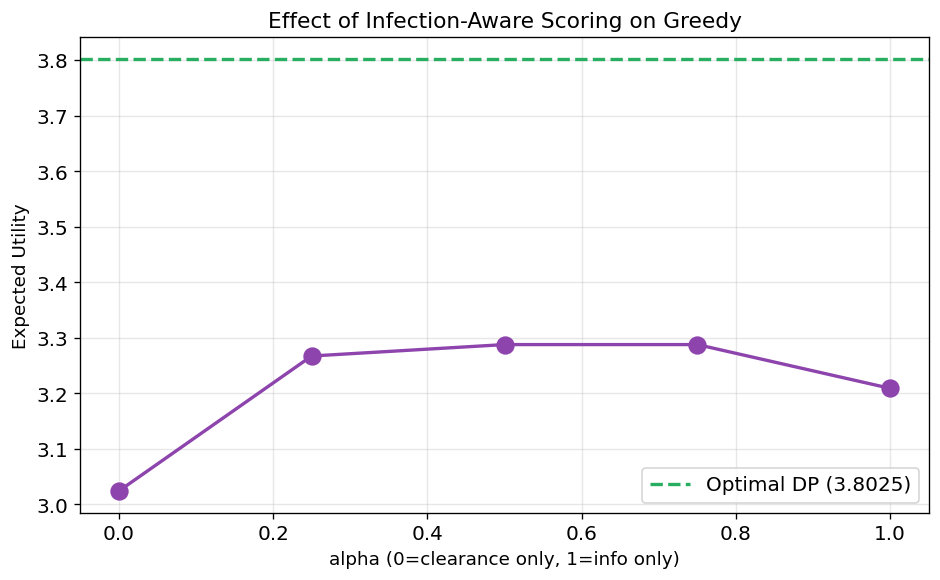

In [31]:
# --- Alpha: Infection-aware scoring ---
n, B, G = 6, 4, 3
p = [0.3] * n
u = [1.0] * n

alpha_values = [0.0, 0.25, 0.5, 0.75, 1.0]
eu_alpha = []

for alpha in alpha_values:
    def make_score_fn(a):
        def fn(cp, u_arg, G_arg, n_arg, cleared_mask):
            return _infection_aware_best_pool(cp, u_arg, G_arg, n_arg, cleared_mask, alpha=a)
        return fn

    _, eu_a = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=B,
                                        greedy_score_fn=make_score_fn(alpha))
    eu_alpha.append(eu_a)
    print(f'alpha={alpha:.2f}: EU = {eu_a:.4f}')

val_opt, _ = solve_optimal_dapts(p, u, B, G)
print(f'Optimal DP: EU = {val_opt:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_values, eu_alpha, 'o-', color=C_INFO, linewidth=2, markersize=10)
ax.axhline(y=val_opt, color=C_OPT, linestyle='--', linewidth=2, label=f'Optimal DP ({val_opt:.4f})')
ax.set_xlabel('alpha (0=clearance only, 1=info only)')
ax.set_ylabel('Expected Utility')
ax.set_title('Effect of Infection-Aware Scoring on Greedy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('appendix_alpha_sweep')
plt.show()


beta=0.0: EU = 2.5350
beta=0.1: EU = 2.5350
beta=0.5: EU = 2.5350
beta=1.0: EU = 2.5350
beta=2.0: EU = 2.5350
beta=5.0: EU = 2.5350


Optimal: 2.5948


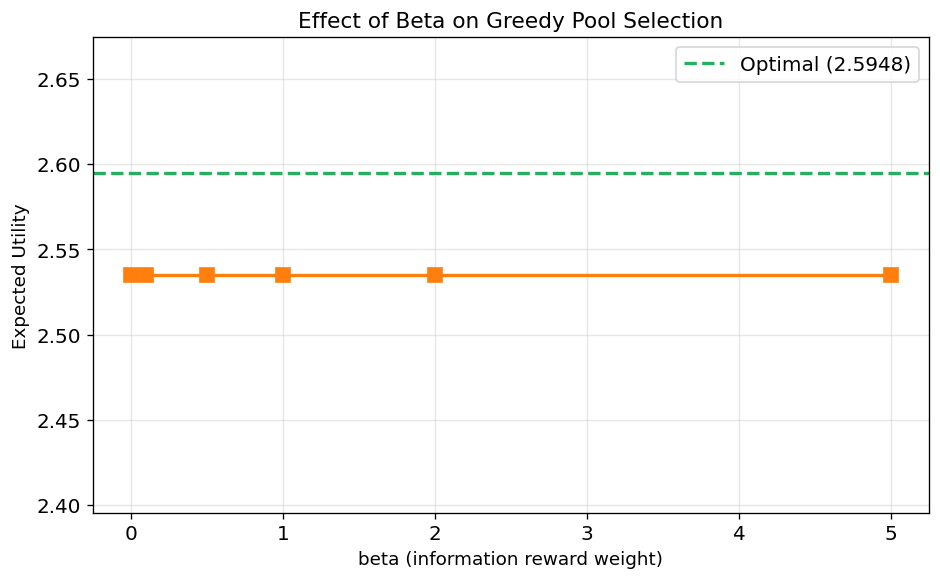

In [32]:
# --- Beta: Information reward ---
n_beta = 6
B_beta, G_beta = 3, 3
p_beta = [0.35] * n_beta
u_beta = [1.0] * n_beta

beta_values = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]

eu_beta_list = []
for beta in beta_values:
    eu = greedy_myopic_beta_expected_utility(p_beta, u_beta, B_beta, G_beta, beta, 'entropy')
    eu_beta_list.append(eu)
    print(f'beta={beta:.1f}: EU = {eu:.4f}')

val_opt_beta, _ = solve_optimal_dapts(p_beta, u_beta, B_beta, G_beta)
print(f'Optimal: {val_opt_beta:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(beta_values, eu_beta_list, 's-', color=C_BETA, linewidth=2, markersize=8)
ax.axhline(val_opt_beta, color=C_OPT, linestyle='--', linewidth=2, label=f'Optimal ({val_opt_beta:.4f})')
ax.set_xlabel('beta (information reward weight)')
ax.set_ylabel('Expected Utility')
ax.set_title('Effect of Beta on Greedy Pool Selection')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('appendix_beta_sweep')
plt.show()


<a id='appD'></a>

---
# Appendix D: Key Comparisons with Nico's Thesis

Two representative reproductions:
1. **Example 4.4** — when greedy picks the wrong pool
2. **Budget scaling** — augmented advantage grows with B


Nico's Example 4.4: n=3, B=2, G=3, p=[1/4]*3
U_max                     2.2500
U_single                  1.5000
Augmented Dynamic         1.8750
Classical Dynamic         1.8750
Greedy Sequential         1.6875
Greedy Counting           1.6875

Augmented advantage: +0.0%


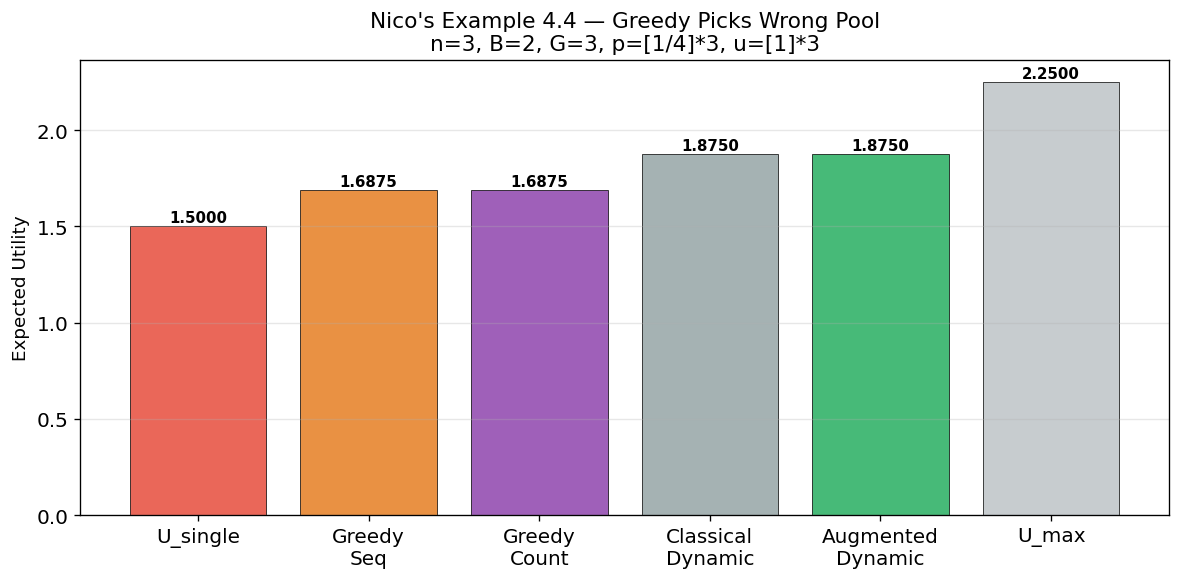

In [33]:
# --- Nico's Example 4.4 ---
n_ex, B_ex, G_ex = 3, 2, 3
p_ex = [0.25, 0.25, 0.25]
u_ex = [1.0, 1.0, 1.0]

val_aug, pol_aug = solve_optimal_dapts(p_ex, u_ex, B_ex, G_ex)
val_cls, _ = solve_classical_dynamic(p_ex, u_ex, B_ex, G_ex)
eu_greedy_seq = greedy_myopic_expected_utility(p_ex, u_ex, B_ex, G_ex)
eu_greedy_cnt = greedy_myopic_counting_expected_utility(p_ex, u_ex, B_ex, G_ex)
eu_umax_ex = u_max(p_ex, u_ex)
eu_single_ex, _ = u_single(p_ex, u_ex, B_ex)

print(f"Nico's Example 4.4: n={n_ex}, B={B_ex}, G={G_ex}, p=[1/4]*3")
print(f"{'U_max':<25} {eu_umax_ex:.4f}")
print(f"{'U_single':<25} {eu_single_ex:.4f}")
print(f"{'Augmented Dynamic':<25} {val_aug:.4f}")
print(f"{'Classical Dynamic':<25} {val_cls:.4f}")
print(f"{'Greedy Sequential':<25} {eu_greedy_seq:.4f}")
print(f"{'Greedy Counting':<25} {eu_greedy_cnt:.4f}")
print(f"\nAugmented advantage: +{(val_aug-val_cls)/val_cls*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
strategies = ['U_single', 'Greedy\nSeq', 'Greedy\nCount', 'Classical\nDynamic',
              'Augmented\nDynamic', 'U_max']
values = [eu_single_ex, eu_greedy_seq, eu_greedy_cnt, val_cls, val_aug, eu_umax_ex]
colors = [C_GREEDY, '#e67e22', C_INFO, C_CLS, C_OPT, '#bdc3c7']

bars = ax.bar(strategies, values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Expected Utility')
ax.set_title("Nico's Example 4.4 — Greedy Picks Wrong Pool\n"
             "n=3, B=2, G=3, p=[1/4]*3, u=[1]*3")
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
savefig('appendix_nico_ex44')
plt.show()


B=1: aug=2.2389, cls=2.2389, static=2.2389
B=2: aug=3.2295, cls=3.1730, static=3.1433


B=3: aug=3.9779, cls=3.7903, static=3.7173


B=4: aug=4.4164, cls=4.2213, static=4.1903


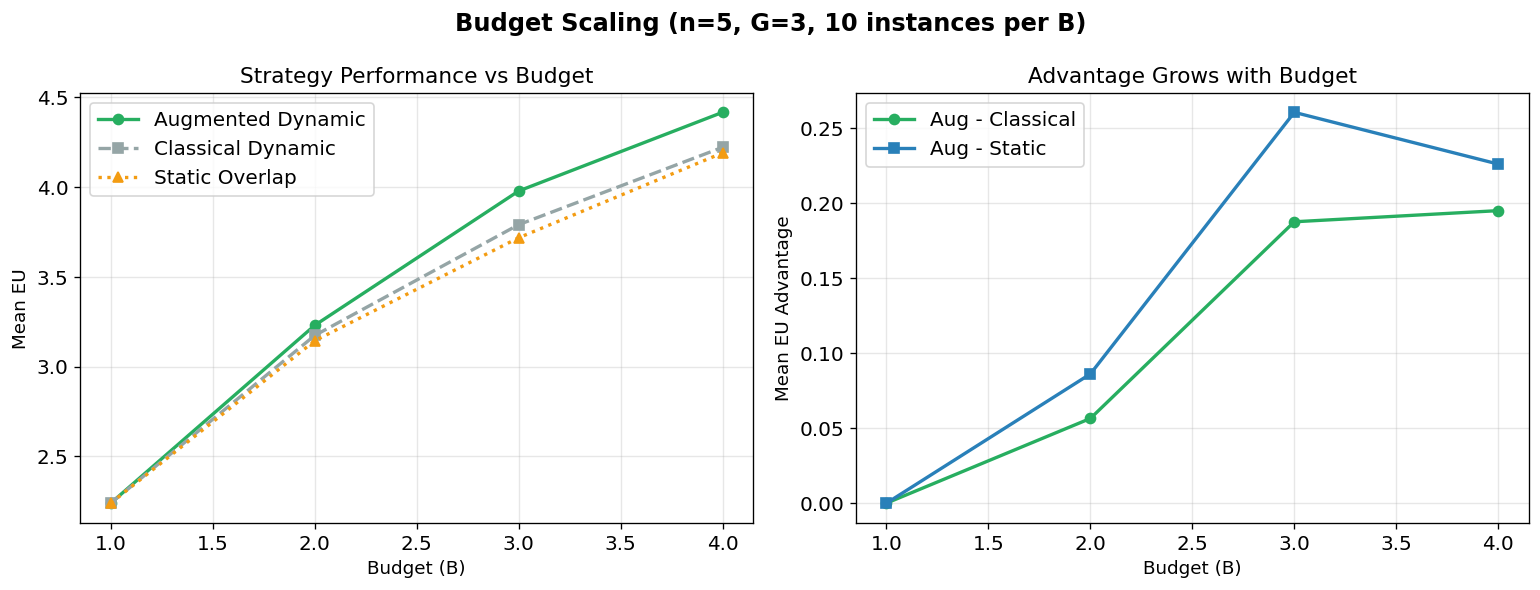

In [34]:
# --- Budget Scaling: augmented advantage grows with B ---
np.random.seed(42)
n_bs = 5
G_bs = 3
B_range = range(1, 5)
N_INST_BS = 10

budget_results = []

for B in B_range:
    aug_vals, cls_vals, static_vals = [], [], []

    for inst in range(N_INST_BS):
        p_inst = np.random.uniform(0.1, 0.9, size=n_bs).tolist()
        u_inst = [float(np.random.choice([1, 2, 3])) for _ in range(n_bs)]

        val_a, _ = solve_optimal_dapts(p_inst, u_inst, B, G_bs)
        val_c, _ = solve_classical_dynamic(p_inst, u_inst, B, G_bs)
        val_s, _ = solve_static_overlapping(p_inst, u_inst, B, G_bs)

        aug_vals.append(val_a)
        cls_vals.append(val_c)
        static_vals.append(val_s)

    budget_results.append({
        'B': B,
        'aug_mean': np.mean(aug_vals), 'cls_mean': np.mean(cls_vals),
        'static_mean': np.mean(static_vals),
        'aug_advantage': np.mean([a - c for a, c in zip(aug_vals, cls_vals)]),
        'adapt_advantage': np.mean([a - s for a, s in zip(aug_vals, static_vals)]),
    })
    print(f'B={B}: aug={np.mean(aug_vals):.4f}, cls={np.mean(cls_vals):.4f}, '
          f'static={np.mean(static_vals):.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

B_vals = [r['B'] for r in budget_results]

ax1.plot(B_vals, [r['aug_mean'] for r in budget_results], 'o-', color=C_OPT,
         linewidth=2, label='Augmented Dynamic')
ax1.plot(B_vals, [r['cls_mean'] for r in budget_results], 's--', color=C_CLS,
         linewidth=2, label='Classical Dynamic')
ax1.plot(B_vals, [r['static_mean'] for r in budget_results], '^:', color=C_STATIC,
         linewidth=2, label='Static Overlap')
ax1.set_xlabel('Budget (B)')
ax1.set_ylabel('Mean EU')
ax1.set_title('Strategy Performance vs Budget')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(B_vals, [r['aug_advantage'] for r in budget_results], 'o-', color=C_OPT,
         linewidth=2, label='Aug - Classical')
ax2.plot(B_vals, [r['adapt_advantage'] for r in budget_results], 's-', color=C_HYBRID,
         linewidth=2, label='Aug - Static')
ax2.set_xlabel('Budget (B)')
ax2.set_ylabel('Mean EU Advantage')
ax2.set_title('Advantage Grows with Budget')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Budget Scaling (n={n_bs}, G={G_bs}, {N_INST_BS} instances per B)',
             fontweight='bold')
plt.tight_layout()
savefig('appendix_budget_scaling')
plt.show()


---
# Summary of Key Findings

| Finding | Section | Key Result |
|---------|---------|------------|
| Full strategy chain holds | Part 2 | U_single ≤ U^s_NO ≤ U^s_O ≤ U^D ≤ U^D_A ≤ U_max |
| Augmentation helps most at moderate prevalence + large G | Part 3 | Regime map + G sweep quantifies when |
| **Augmented advantage grows with B (up to B=8)** | **Part 3B** | **Paired instances, VIP saturation** |
| **Cross-test info is the key mechanism** | **Part 3C** | **Counting - sequential gap grows with B** |
| Hybrid solver is practical | Part 4 | Pareto frontier + n=10-14 transition zone |
| **Greedy suffices for small B, not large** | **Part 4B** | **Gap heatmap across (n, B)** |
| **Augmented stays ahead under misspecification** | **Part 5** | **Both aug & classical compared** |
| Dynamic has higher mean but also risk | Part 6 | P(w=0) and CVaR analysis |
| Application-dependent advantage | Part 7 | 5 scenarios incl. p>0.7 + bimodal |
